# Manual inspection and intermediate figures

To generate any other useful figures after integrate or inspect.

In [40]:
import scanpy as sc
import scvi as scvi
import anndata as ad
import pandas as pd
import numpy as np
import sys
import seaborn as sns
import os
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

import matplotlib.pyplot as plt
%matplotlib inline
sc.set_figure_params(figsize=(5,5), dpi=400)

In [41]:
integrated = '/root/capsule/data/260807_cmg_int_round_02/rounds/round_02/integrated.h5ad'

In [42]:
adata = ad.read_h5ad(integrated)
adata.obs.groupby('tech').size()

/tmp/ipykernel_178/591211242.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('tech').size()


tech
10x_Multiome    1129
SSv4             397
dtype: int64

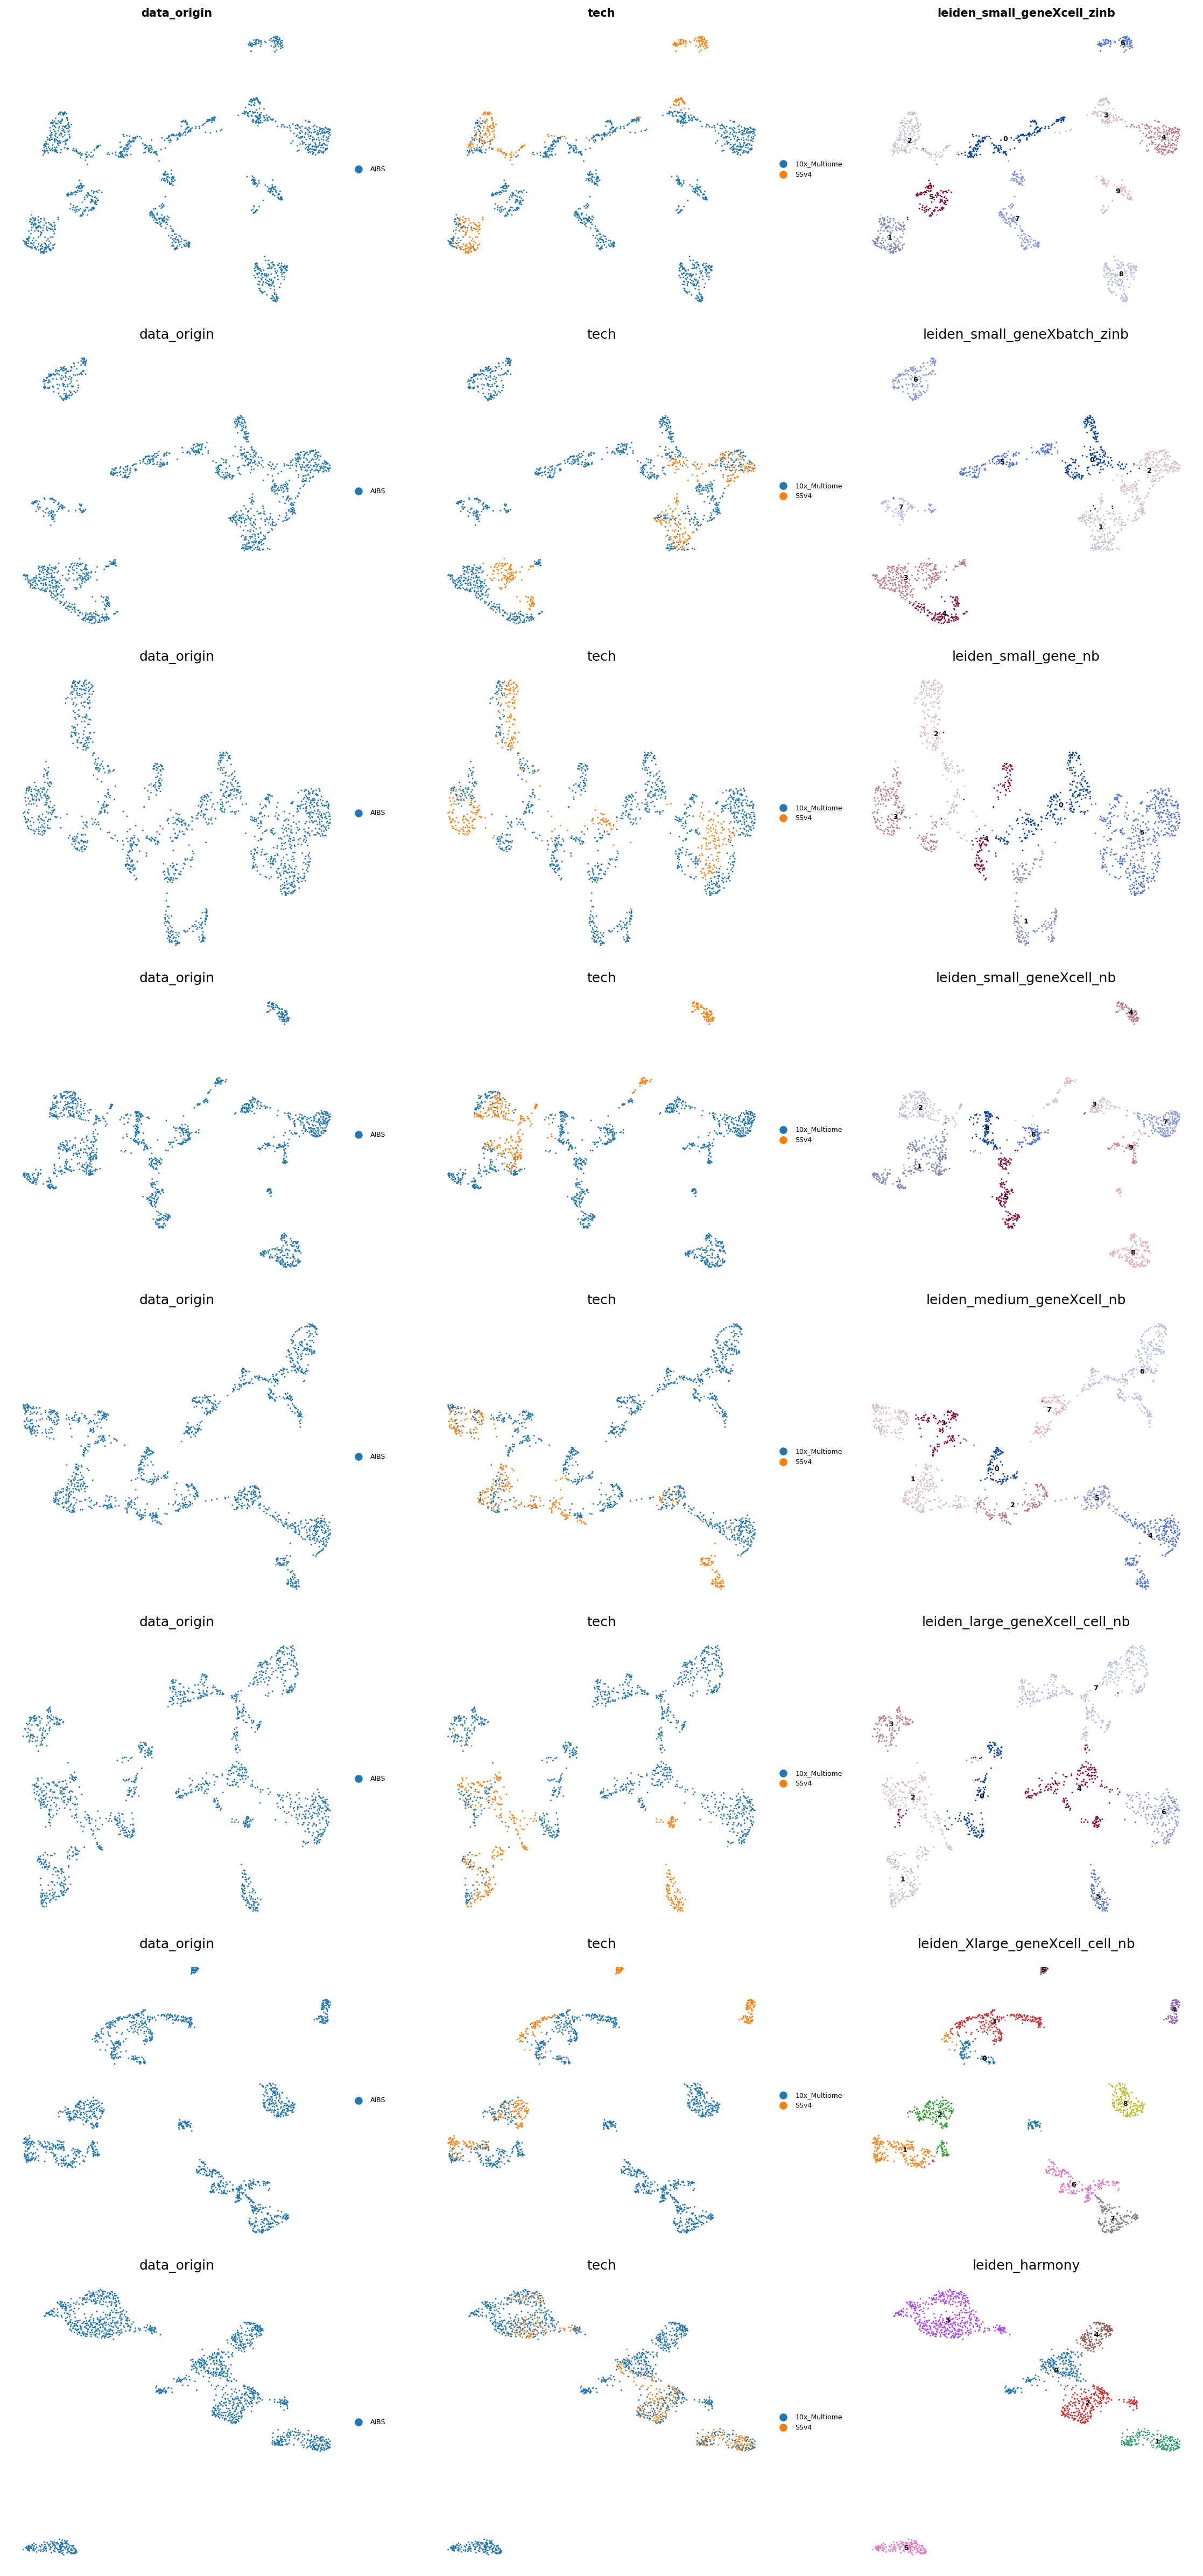

In [43]:
# display the UMAPs
from IPython.display import Image
Image(filename='/root/capsule/data/260807_cmg_int_round_02/rounds/round_02/umap_config_comparison.png') 

In [44]:
# Cluster key: leiden_Xlarge_geneXcell_cell_nb · Batch key: tech · Cells: 262,734 · Genes: 32,569 · latent_key: X_scVI_Xlarge_geneXcell_cell_nb · umap_key: X_umap_Xlarge_geneXcell_cell_nb · cluster_key: leiden_Xlarge_geneXcell_cell_nb

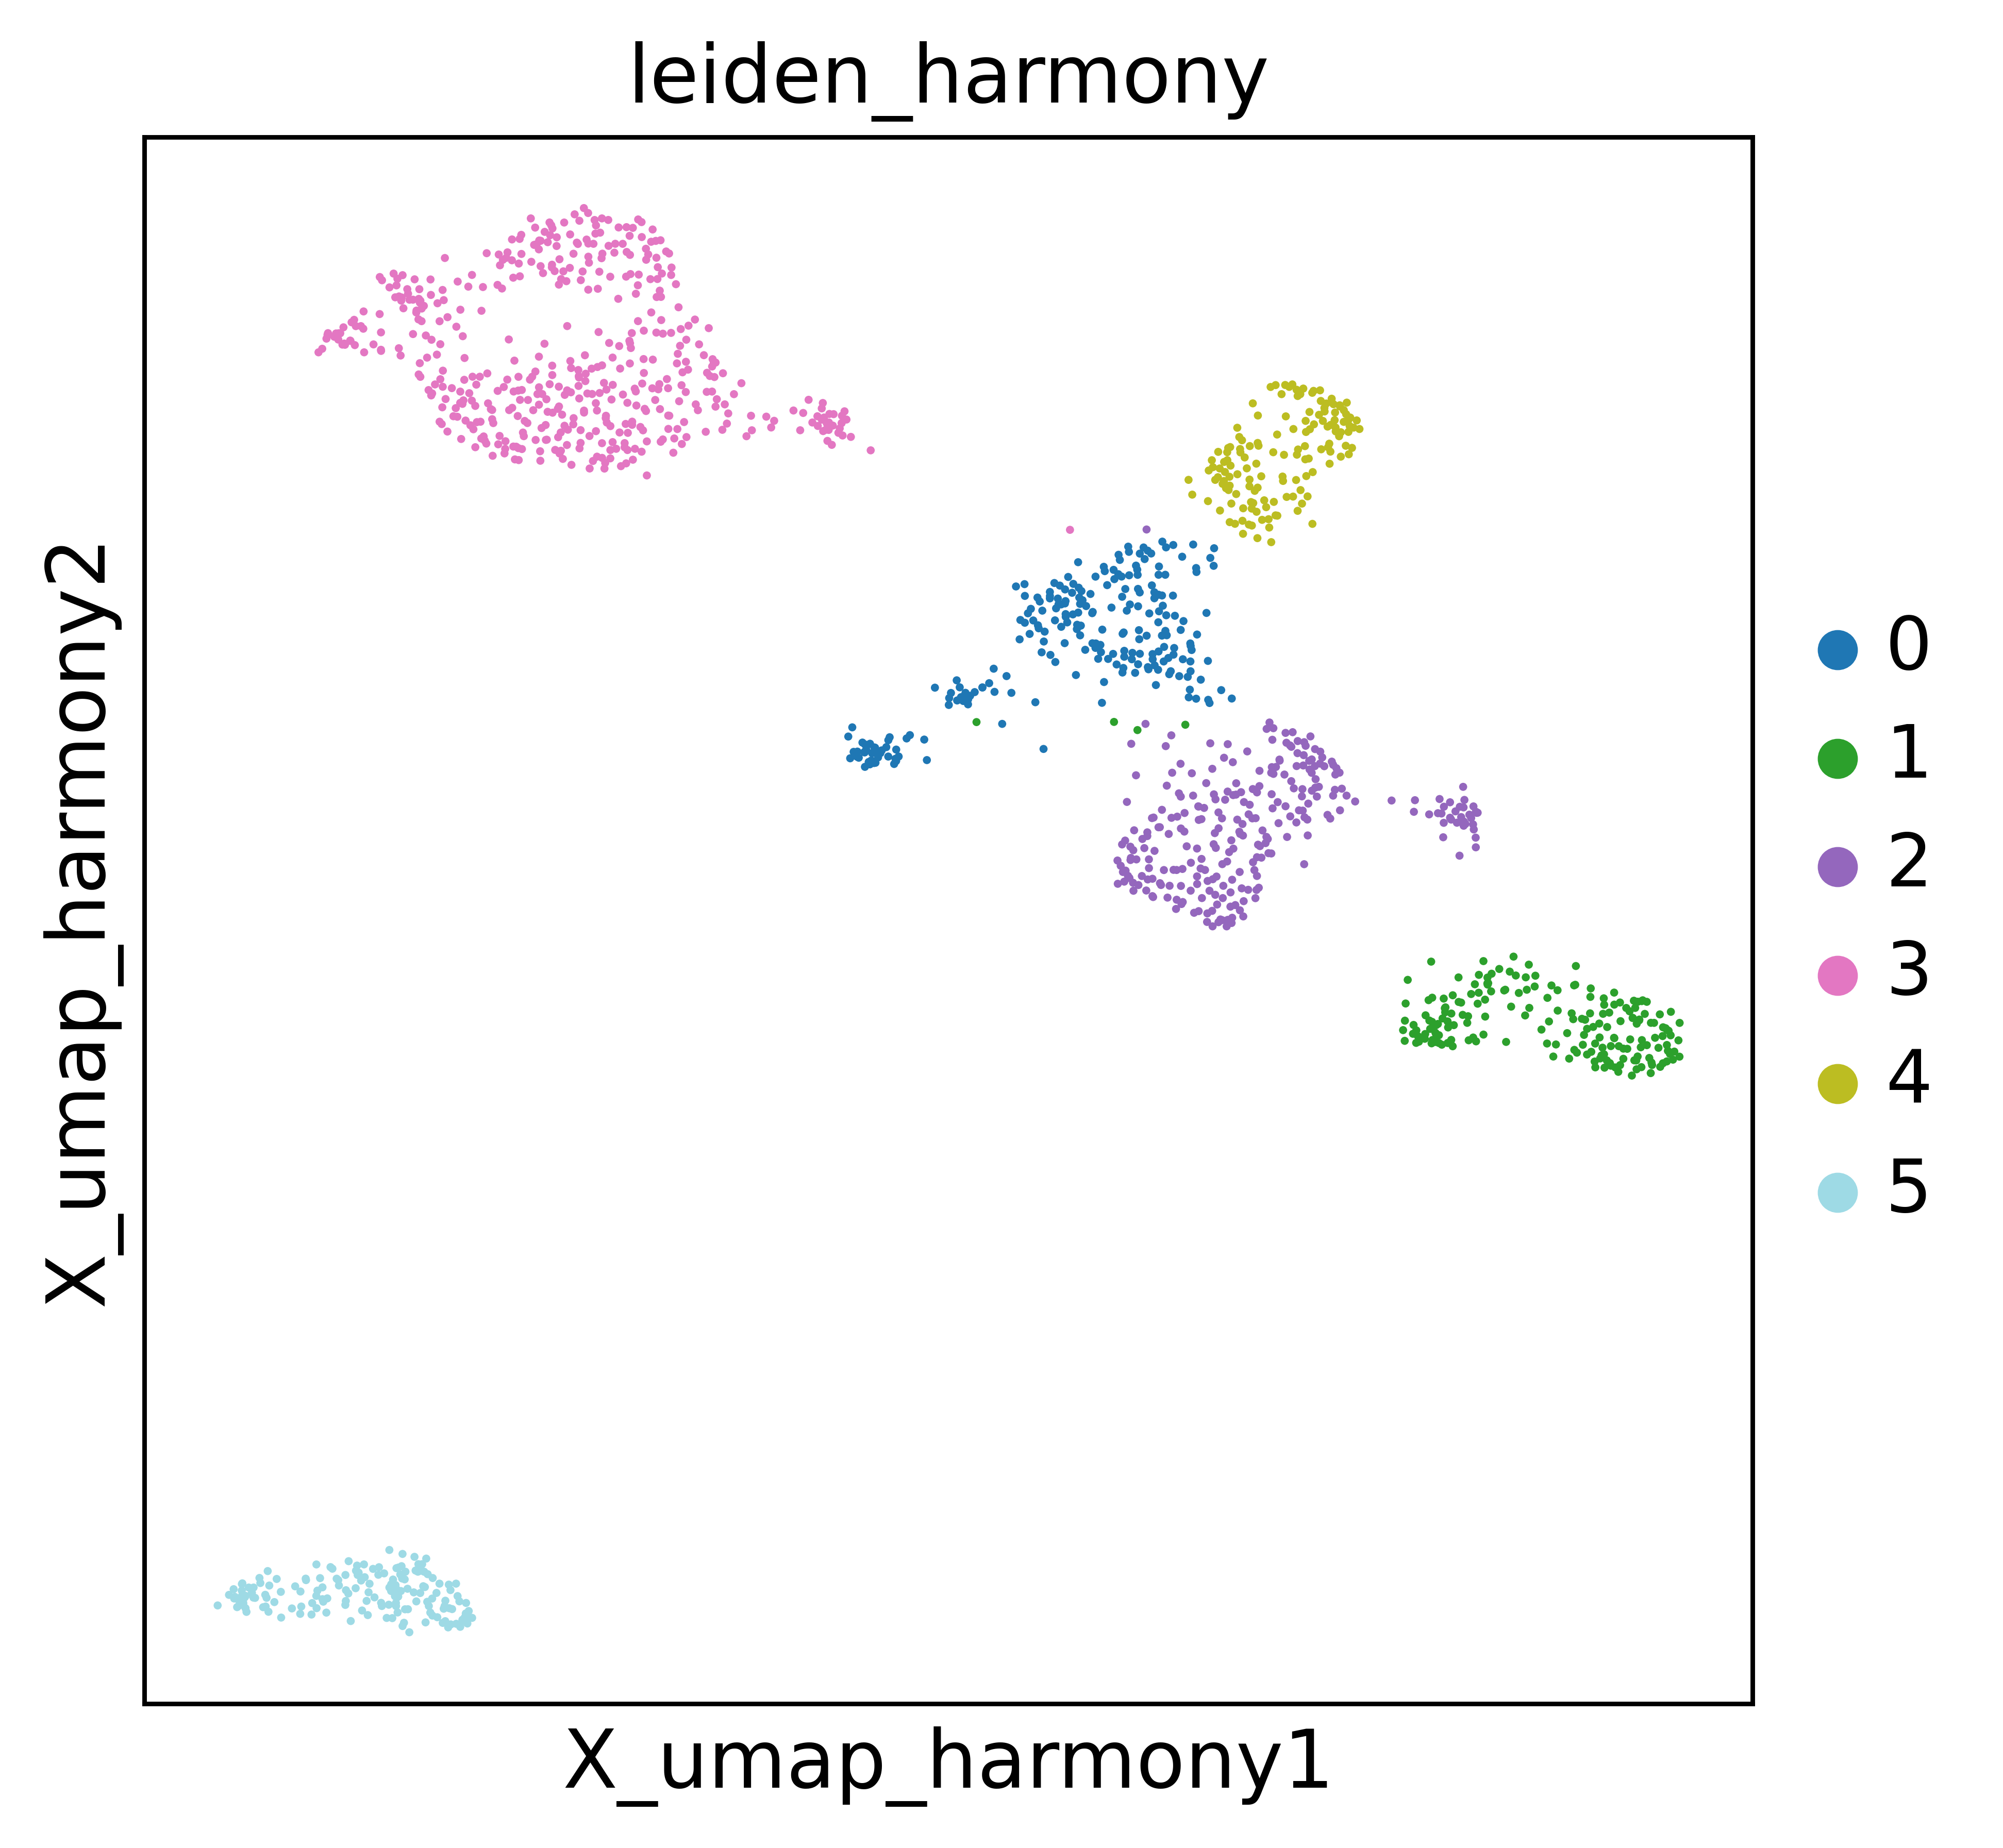

In [47]:
embedding = 'X_umap_harmony'
clusters = 'leiden_harmony'

sc.pl.embedding(adata,basis=embedding,color = clusters, size = 8, palette = 'tab20')

In [46]:
#sc.pl.embedding(adata,basis=embedding,color = clusters,groups=['4','20'], na_color='#d3d3d3',size =20, palette = 'tab20')

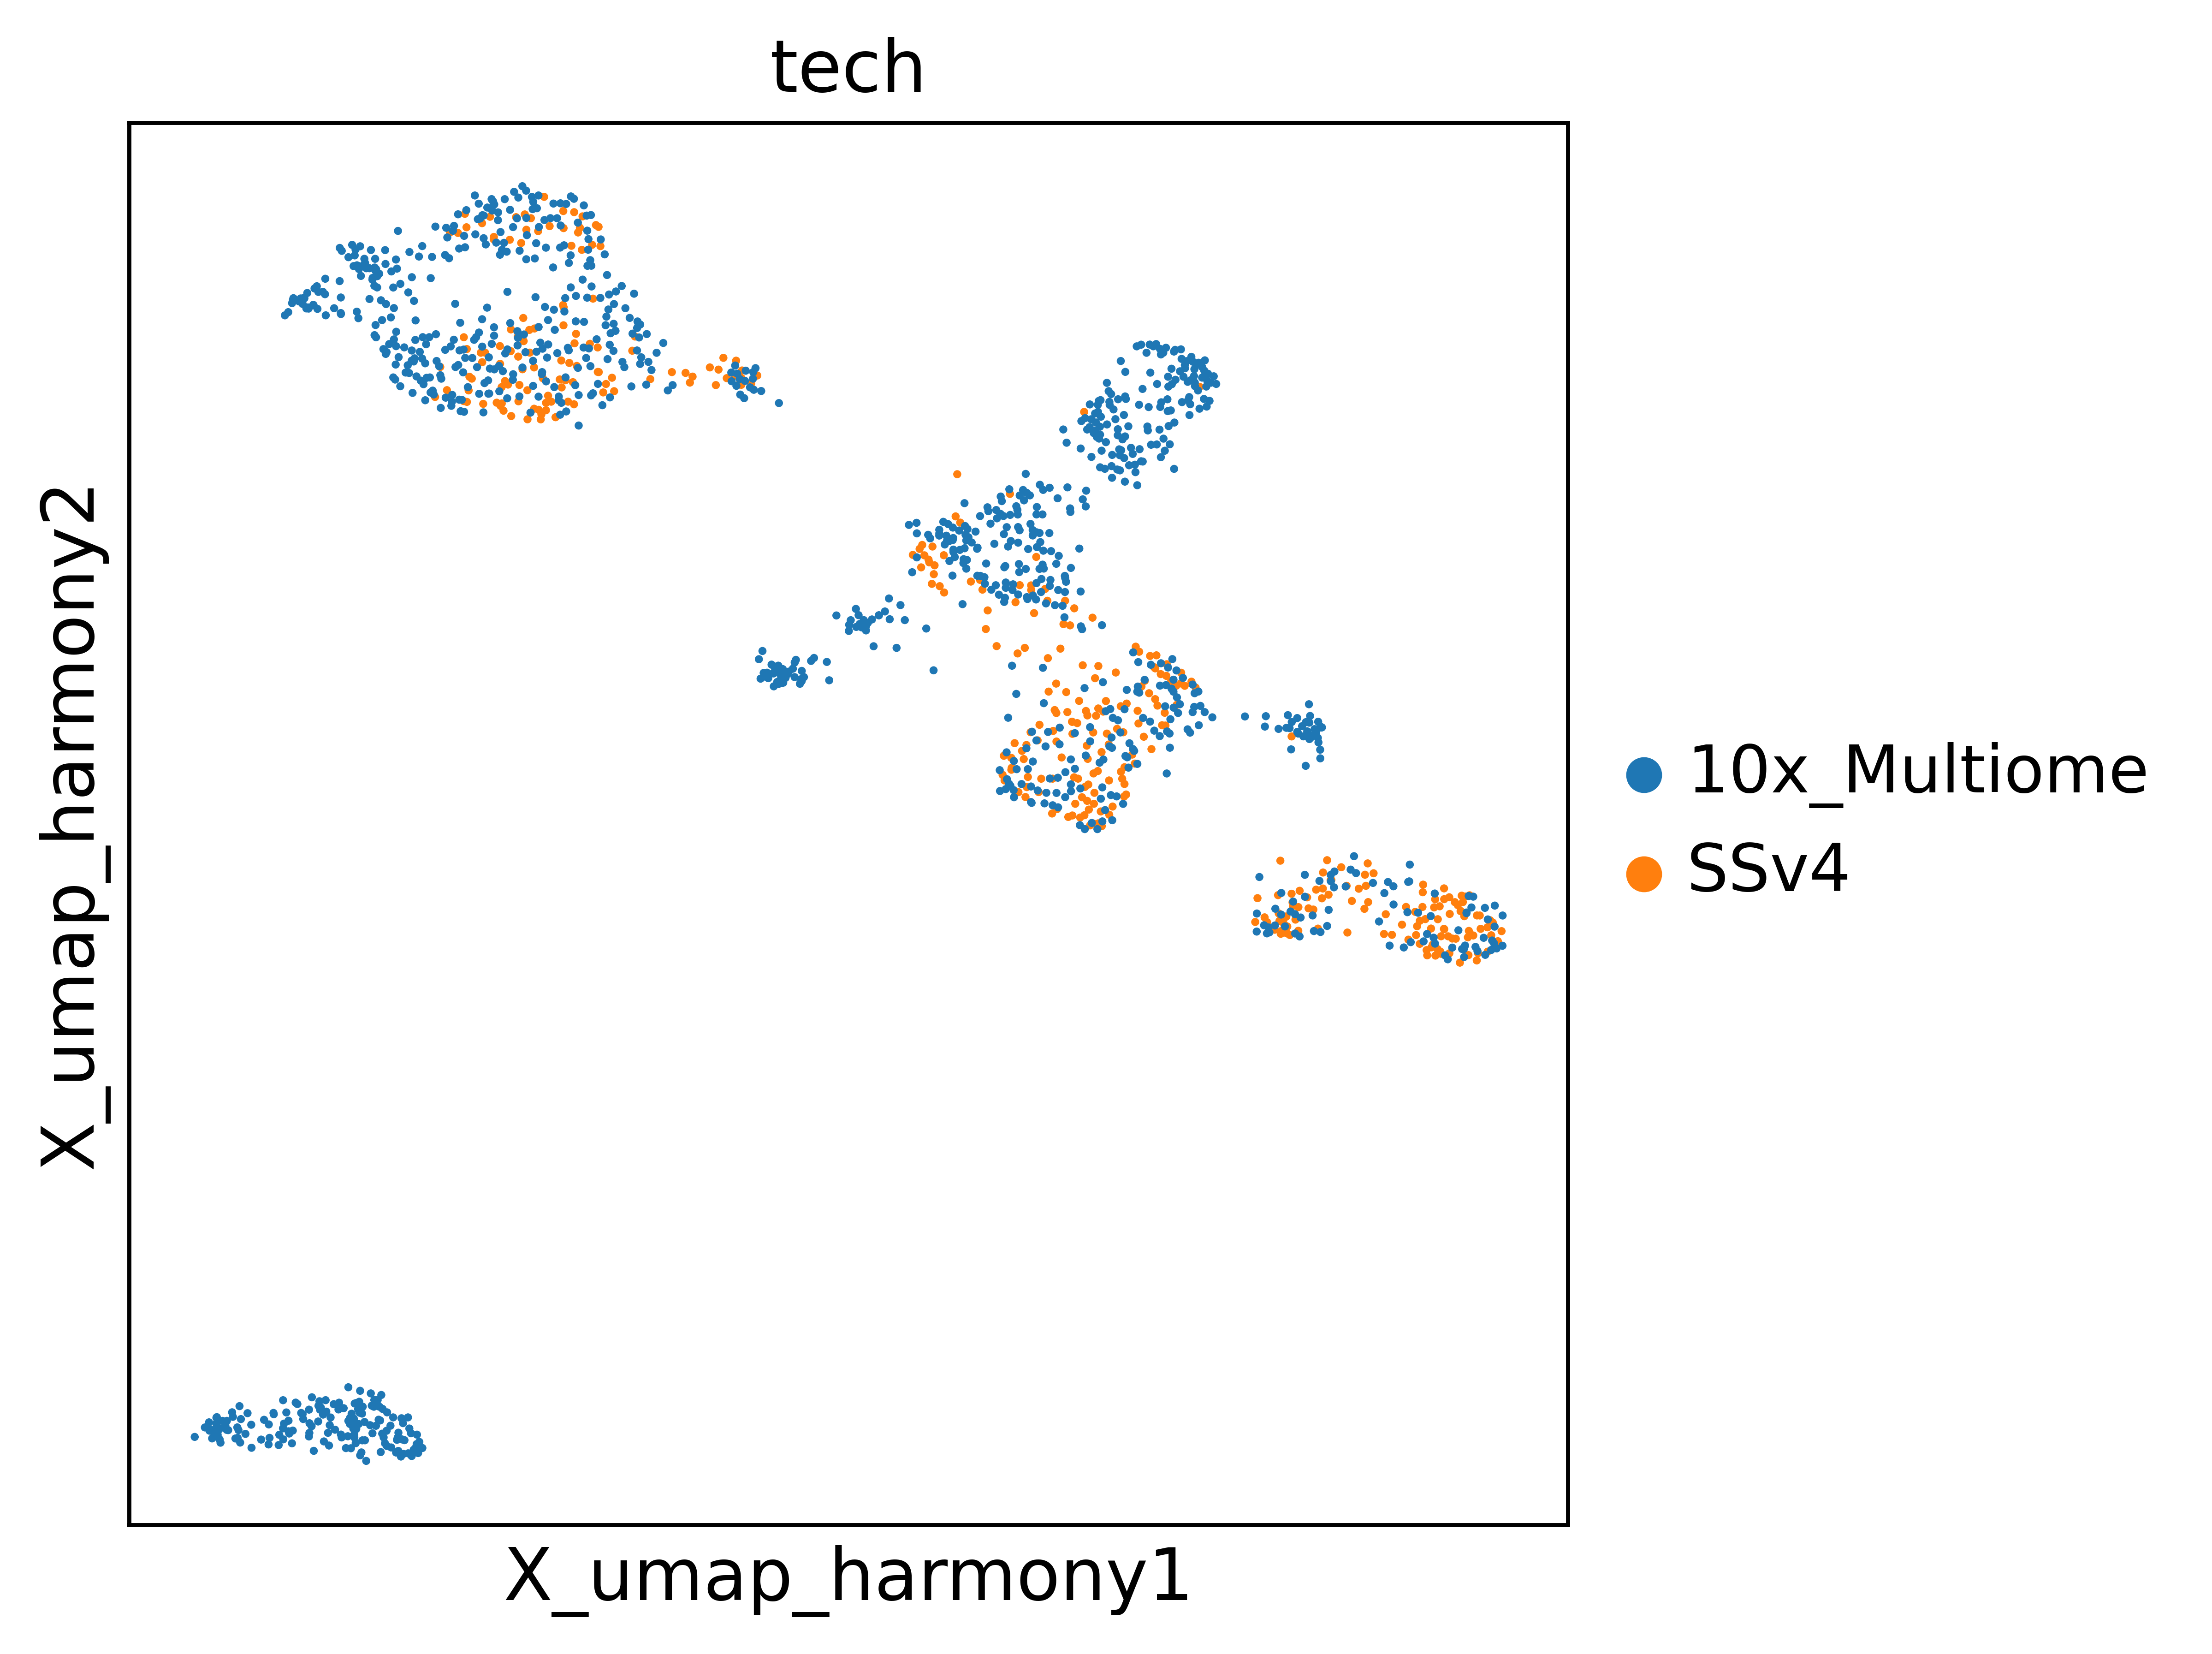

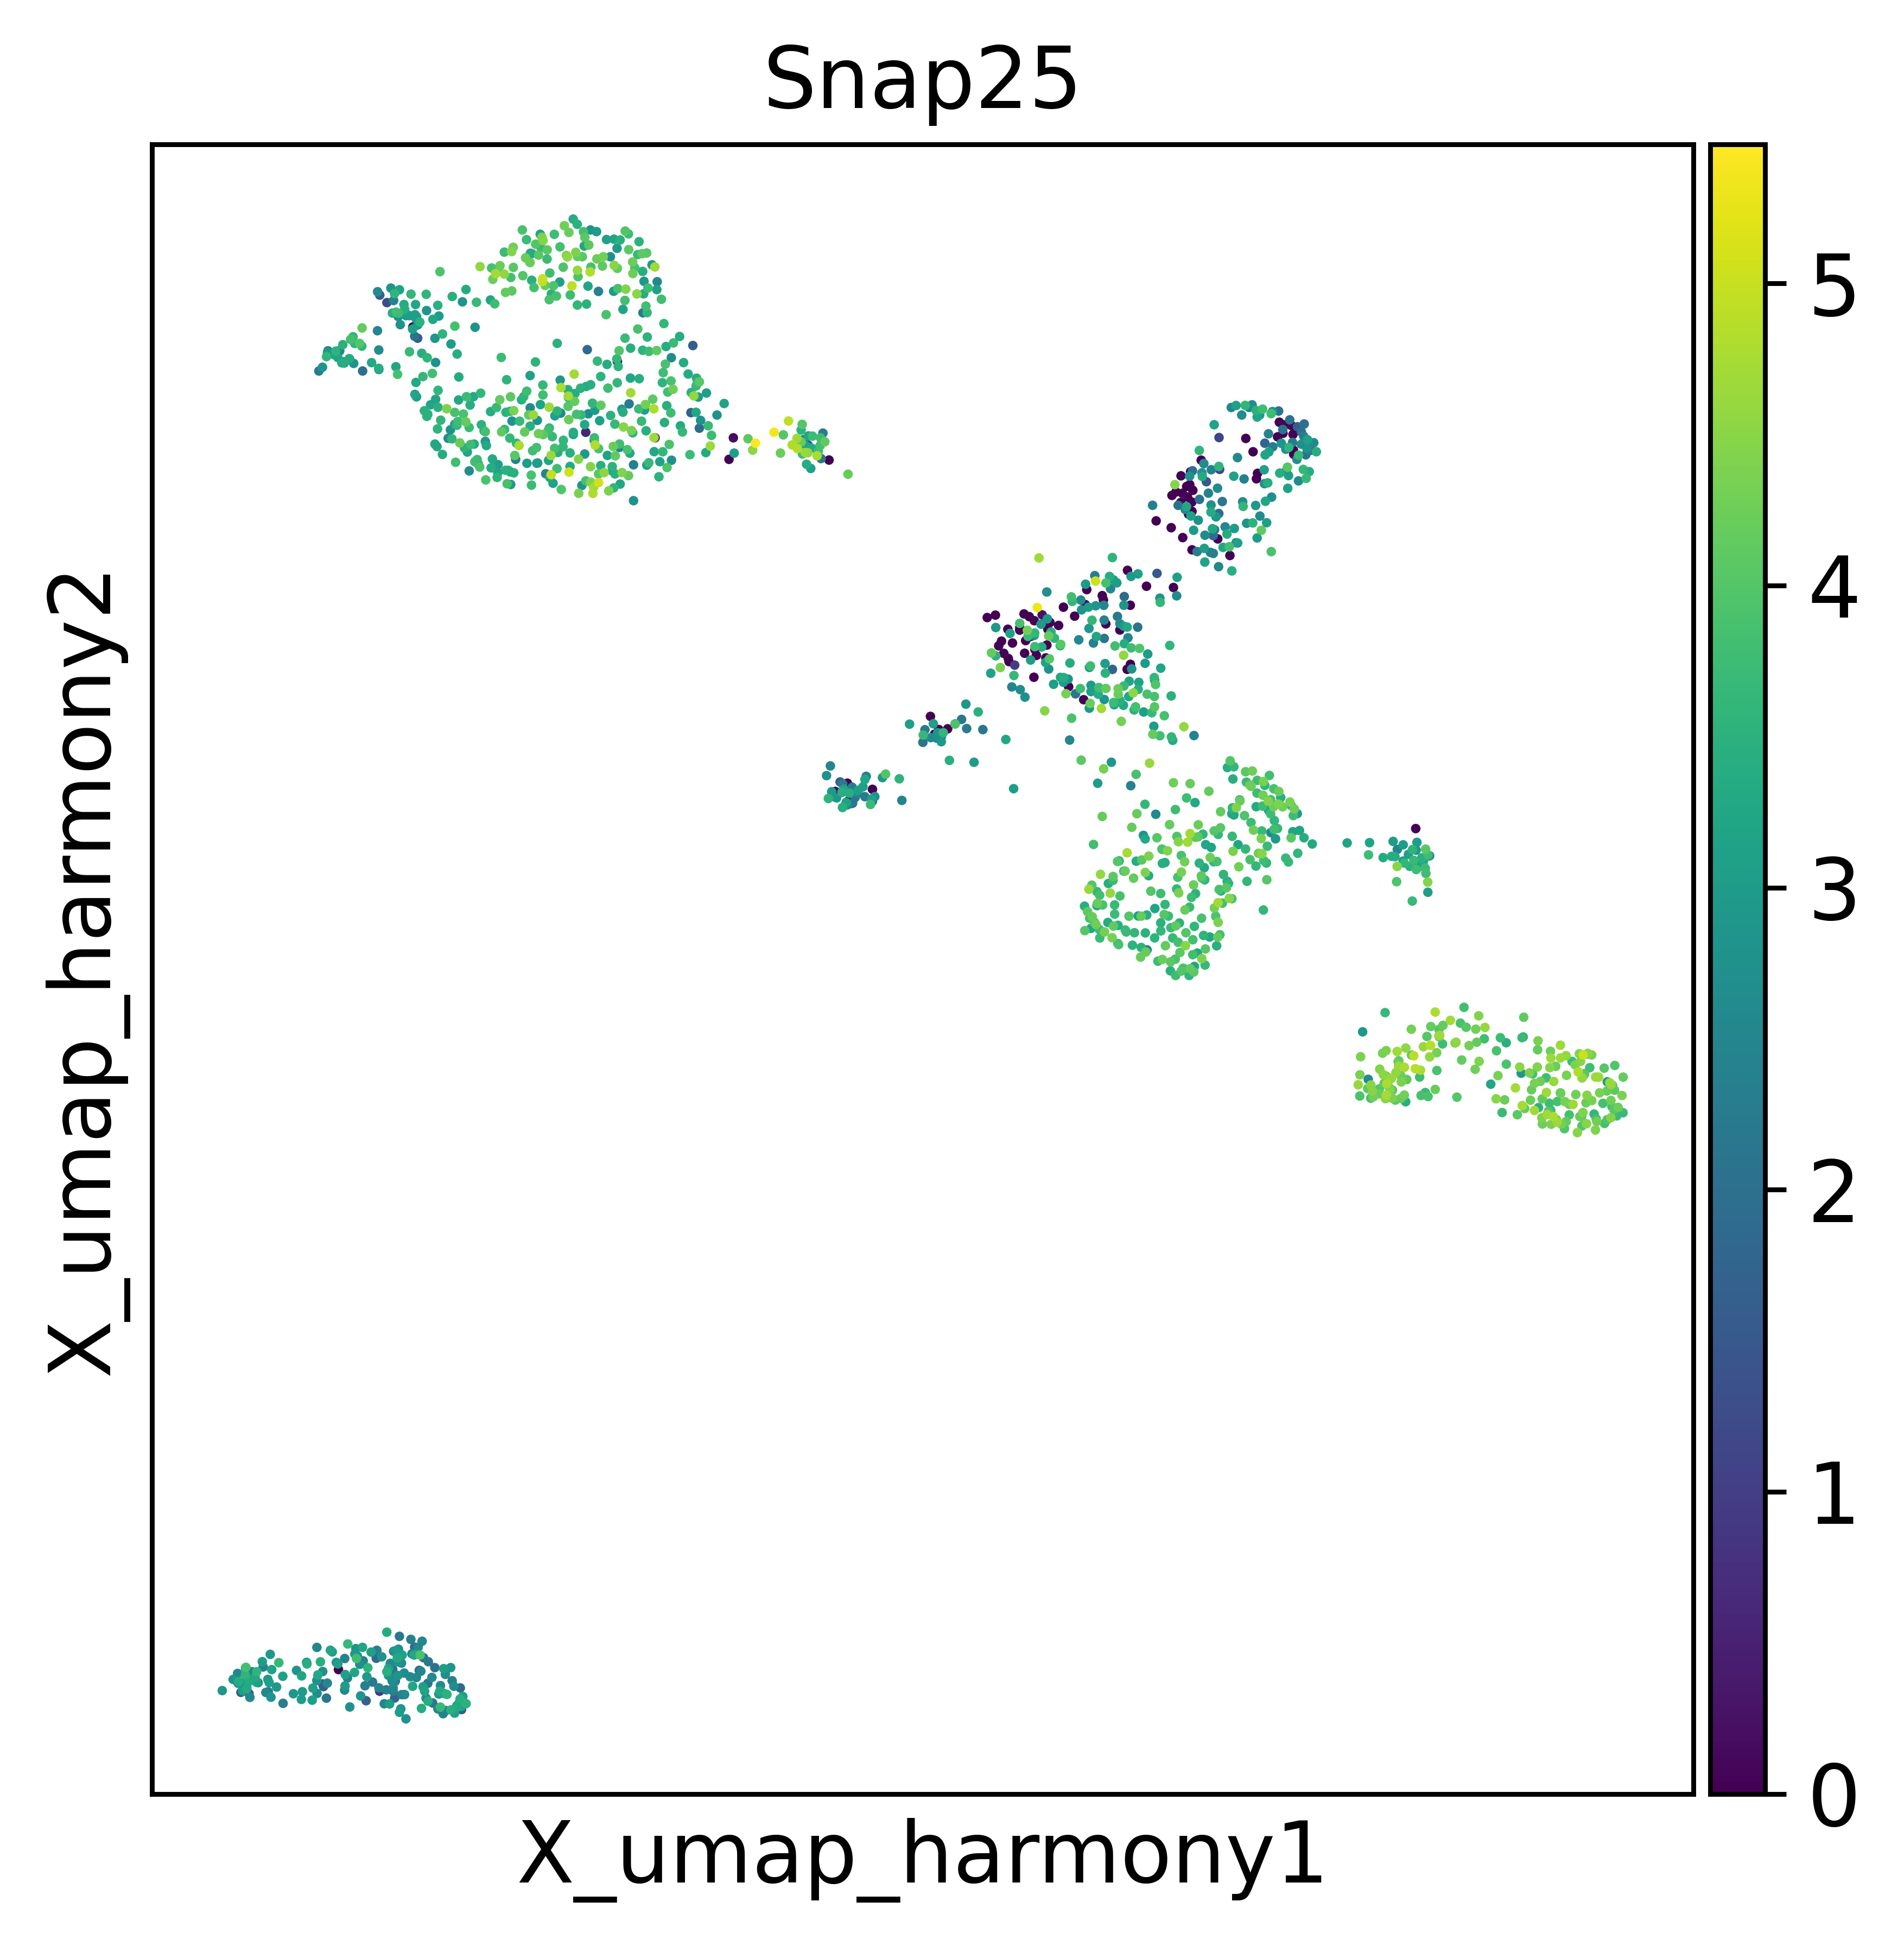

In [48]:
sc.pl.embedding(adata,basis=embedding,color = 'tech',size =10)
sc.pl.embedding(adata,basis=embedding,color = 'Snap25',size =10)

In [10]:
adata

AnnData object with n_obs × n_vars = 1526 × 29985
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'animal_id', 'doublet_score', 'mito.ratio', 'malat1', 'sex', 'age', 'load_name', 'condition', 'columbia_id', 'condition_fine', 'replicates', 'genotype', 'gene_counts', 'umi_counts', 'umi_flag', 'low_count_flag', 'high_count_flag', 'tech', 'exclude.ssv4', 'batch', 'facs.date', 'ssv4.well', 'FACS.Date', 'pcr_cycles', 'sample_name', 'percent_reads_aligned_total', 'complexity_cg', 'genes_detected_cpm', 'genes_detected', 'percent_reads_aligned_to_synthetic_constructs', 'exclude2', 'mapped_reads', 'qc.score', 'umi', 'total.umi', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'sample_id', 'library_prep', 'barcodes', 'LabTracksID', 'dissection_method', 'mito.perc', 'full_harmony25_clusters_1.0', 'seurat_clusters', 'full_harmony25_clusters_0.6', 'nCount_OriginalRNA', 'nFeature_OriginalRNA', 'data_o

In [49]:
# generate a new UMAP with 3 dimensions
# 1. Point scanpy to use your custom neighbor graph keys
key = "neighbors_harmony"

# 2. Run UMAP requesting 3 components
sc.tl.umap(
    adata,
    n_components=3,
    neighbors_key=key
)

adata.obsm['X_umap_harmony_3d'] = adata.obsm['X_umap'].copy()

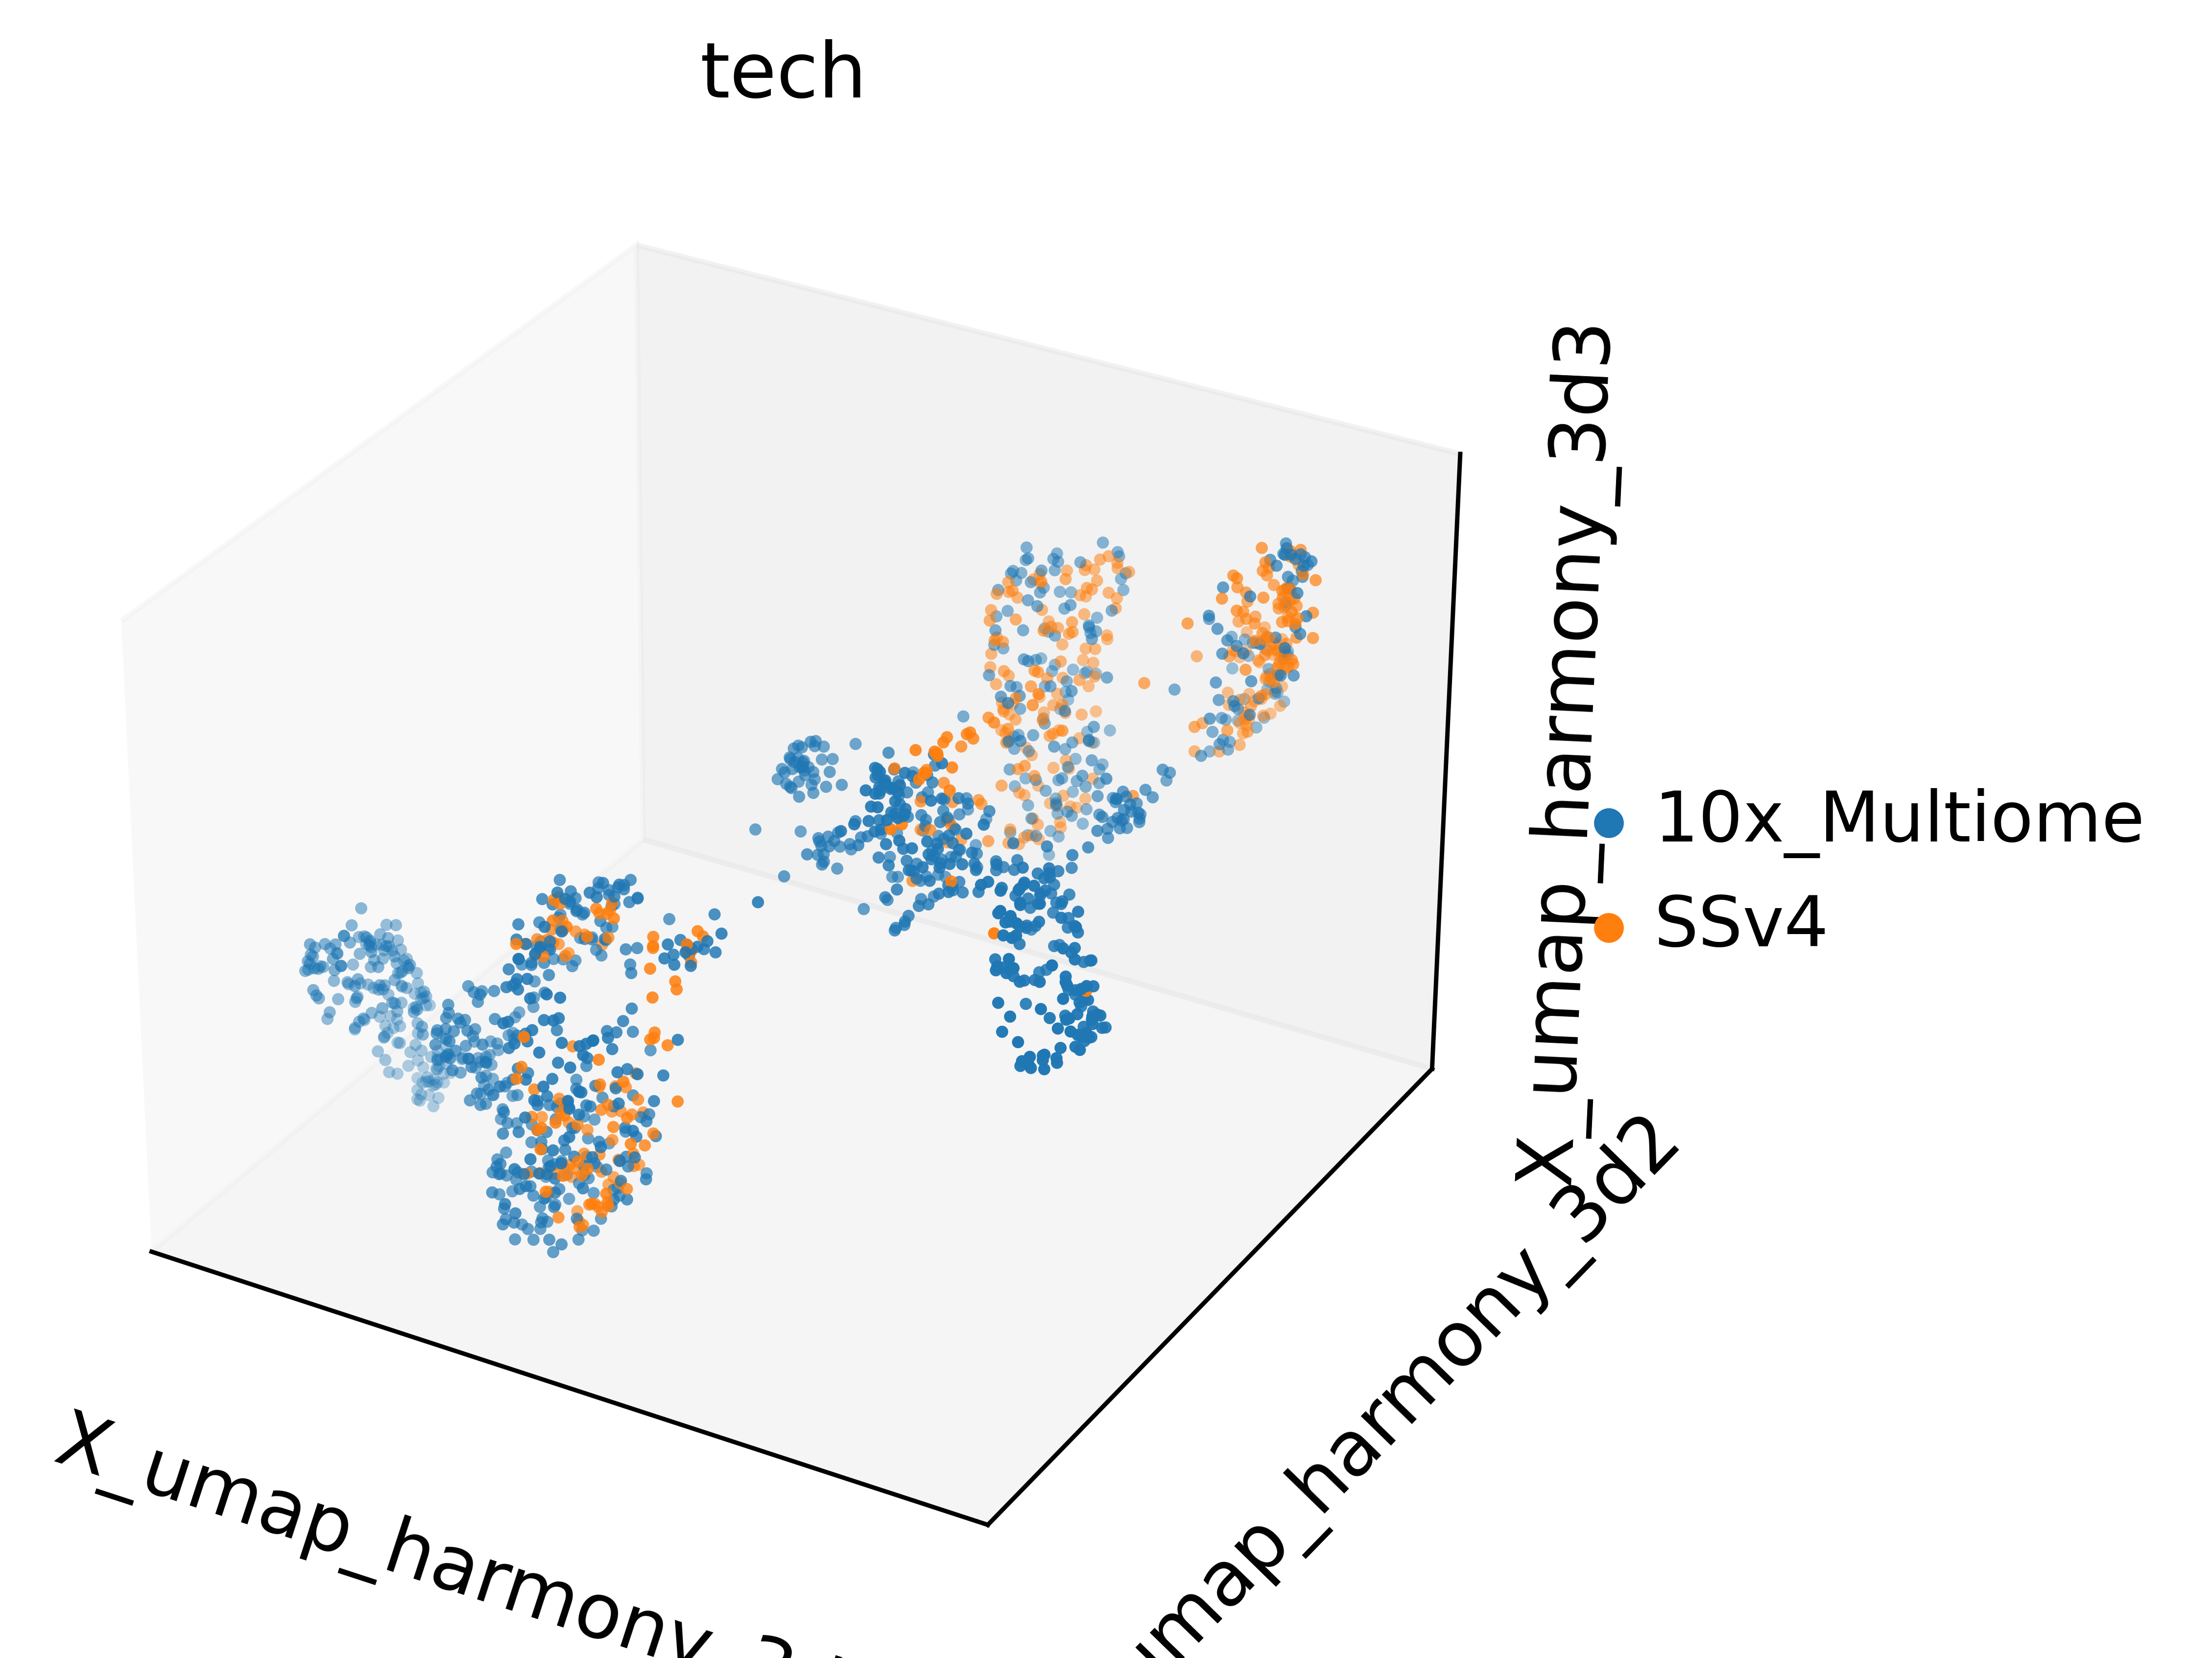

In [52]:
sc.pl.embedding(adata,basis='X_umap_harmony_3d',projection = '3d', color = 'tech', size = 4)

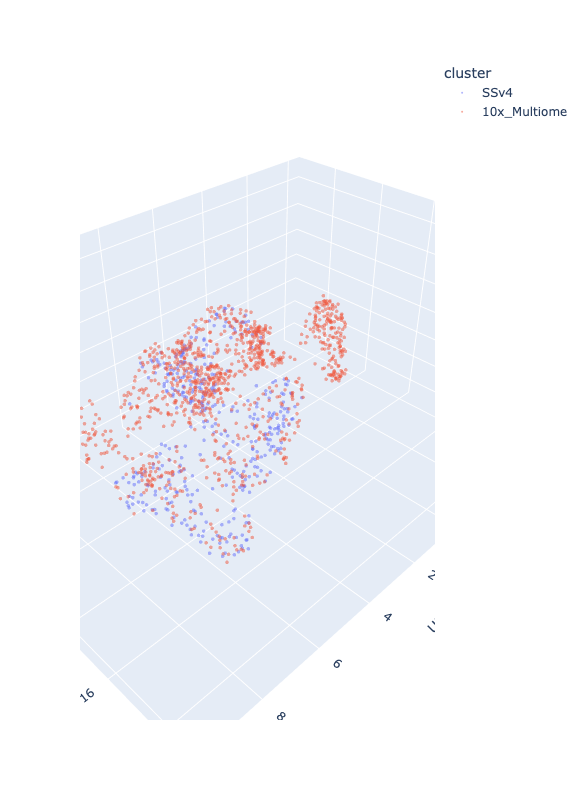

In [53]:
# Optional: Interactive 3D visualization using Plotly
import plotly.express as px
umap_3d_coords = adata.obsm["X_umap_harmony_3d"]
df_3d = pd.DataFrame(
    umap_3d_coords,
    columns=["UMAP1", "UMAP2", "UMAP3"],
    index=adata.obs_names,
)
df_3d["cluster"] = adata.obs['tech']  

fig = px.scatter_3d(
    df_3d,
    x="UMAP1",
    y="UMAP2",
    z="UMAP3",
    color="cluster",
    size_max=1,
    hover_data="cluster",
    opacity=0.5
)
fig.update_layout(
    width=1000,  # width in pixels
    height=800   # height in pixels
)
fig.update_traces(marker_size = 2)
fig.show()

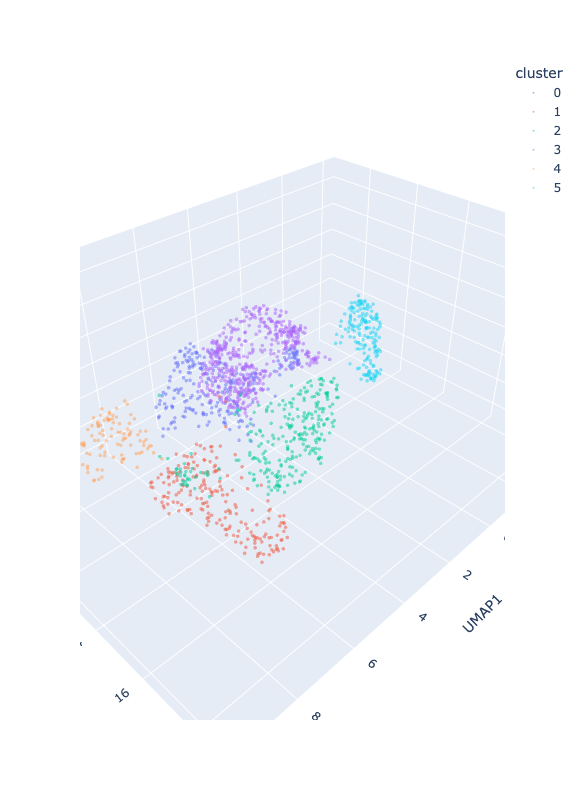

In [54]:
umap_3d_coords = adata.obsm["X_umap_harmony_3d"]
df_3d = pd.DataFrame(
    umap_3d_coords,
    columns=["UMAP1", "UMAP2", "UMAP3"],
    index=adata.obs_names,
)
df_3d["cluster"] = adata.obs[clusters]  

fig = px.scatter_3d(
    df_3d,
    x="UMAP1",
    y="UMAP2",
    z="UMAP3",
    color="cluster",
    size_max=1,
    hover_data="cluster",
    opacity=0.5
)
fig.update_layout(
    width=1000,  # width in pixels
    height=800   # height in pixels
)
fig.update_traces(marker_size = 2)
fig.show()

In [55]:
import sccairns
from sccairns.record_filter import record_filter

In [39]:
#record_filter()
adata

AnnData object with n_obs × n_vars = 1526 × 29985
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'animal_id', 'doublet_score', 'mito.ratio', 'malat1', 'sex', 'age', 'load_name', 'condition', 'columbia_id', 'condition_fine', 'replicates', 'genotype', 'gene_counts', 'umi_counts', 'umi_flag', 'low_count_flag', 'high_count_flag', 'tech', 'exclude.ssv4', 'batch', 'facs.date', 'ssv4.well', 'FACS.Date', 'pcr_cycles', 'sample_name', 'percent_reads_aligned_total', 'complexity_cg', 'genes_detected_cpm', 'genes_detected', 'percent_reads_aligned_to_synthetic_constructs', 'exclude2', 'mapped_reads', 'qc.score', 'umi', 'total.umi', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'sample_id', 'library_prep', 'barcodes', 'LabTracksID', 'dissection_method', 'mito.perc', 'full_harmony25_clusters_1.0', 'seurat_clusters', 'full_harmony25_clusters_0.6', 'nCount_OriginalRNA', 'nFeature_OriginalRNA', 'data_o

In [56]:
# higher resolution clustering 

sc.tl.leiden(adata,neighbors_key="neighbors_harmony",resolution=2,key_added="leiden_2.0")
sc.tl.leiden(adata,neighbors_key="neighbors_harmony",resolution=1,key_added="leiden_1.0")

In [36]:
sc.pl.embedding(adata,basis=embedding,color = ['leiden_harmony','leiden_2.0','leiden_1.0'],size =10)


In [18]:
qc = sc.pp.calculate_qc_metrics(adata)
qc = pd.DataFrame(qc[0])
qc["tech"] = adata.obs["tech"].values
qc["leiden_harmony"] = adata.obs["leiden_harmony"].values
qc["leiden_1.0"] = adata.obs["leiden_1.0"].values

In [19]:
qc

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,tech,leiden_harmony,leiden_1.0
AB-S40360_S744_E1-50,3402,8.132413,5013.938177,8.520176,4.403379,8.169774,15.023566,33.344504,SSv4,0,4
AB-S40361_S562_E1-50,6988,8.852093,6746.457392,8.816921,3.412769,6.119433,10.876271,23.046211,SSv4,1,2
AB-S40361_S565_E1-50,7054,8.861492,7605.104849,8.936706,2.945722,5.329731,9.517875,19.923650,SSv4,2,1
AB-S40361_S569_E1-50,6689,8.808369,7375.579238,8.906065,3.083371,5.582871,9.997523,20.955283,SSv4,2,1
AB-S40361_S571_E1-50,8218,9.014204,8476.226899,9.045139,2.494473,4.596742,8.317805,17.867479,SSv4,2,1
...,...,...,...,...,...,...,...,...,...,...,...
TTGAGCTAGAGCCGCT-L8XR_250123_21_C08-68cc52a35d408ad9ac877c3b9f22592fed4dc9d8,1933,7.567346,4660.035613,8.446993,4.865872,8.699682,15.588340,33.570112,10x_Multiome,0,4
TTGCAATCAGGCATCT-L8XR_250123_21_C08-68cc52a35d408ad9ac877c3b9f22592fed4dc9d8,1023,6.931472,2752.097289,7.920482,7.797494,13.600738,24.230173,51.849794,10x_Multiome,0,4
TTGGAGGCACTTGTTC-L8XR_250123_21_C08-68cc52a35d408ad9ac877c3b9f22592fed4dc9d8,732,6.597146,2371.508918,7.771703,9.276663,17.221005,30.509291,69.695781,10x_Multiome,0,4
TTGTCCCAGCATGCAT-L8XR_250123_21_C08-68cc52a35d408ad9ac877c3b9f22592fed4dc9d8,688,6.535241,2137.899640,7.668047,10.268569,18.307448,32.200739,73.880613,10x_Multiome,0,4


In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Density normalization works similarly via stat='density' or common_norm
sns.histplot(
    data=qc, 
    x='total_counts', 
    hue='tech', 
    stat='density', 
    common_norm=False, 
    element='step',  # Use 'bars' for solid overlapping bars
    alpha=0.4        # Transparency
)

<Axes: xlabel='pct_counts_mt', ylabel='0'>

In [21]:
sns.histplot(
    data=qc, 
    x='n_genes_by_counts', 
    hue='tech', 
    stat='density', 
    common_norm=False, 
    element='step',  # Use 'bars' for solid overlapping bars
    alpha=0.4        # Transparency
)

<Axes: title={'center': 'leiden_1.0'}, xlabel='X_umap_harmony1', ylabel='X_umap_harmony2'>

In [32]:
def ridgeplot(
    adata,
    cluster_key: str,
    qc_var: str,
    hue_key: str = None,
    palette=None,
    row_height: float = 0.6,
    hspace: float = -0.3,
    figsize_width: float = 8,
    xlabel: str = None,
    title: str = None,
):
    """
    Ridgeplot of a QC variable faceted by cluster.

    Parameters
    ----------
    adata       : AnnData
    cluster_key : obs column for rows (e.g. 'leiden')
    qc_var      : obs column to plot on x-axis (e.g. 'n_genes_by_counts')
    hue_key     : obs column for color splits (e.g. 'tech'); optional
    palette     : dict or seaborn palette name; auto-generated if None
    row_height  : height per row — lower = more overlap
    hspace      : negative values create overlap between rows
    figsize_width, xlabel, title : cosmetics
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    df = adata.obs[[cluster_key, qc_var] + ([hue_key] if hue_key else [])].copy()

    clusters = (
        df[cluster_key].cat.categories.tolist()
        if hasattr(df[cluster_key], "cat")
        else sorted(df[cluster_key].unique())
    )
    n = len(clusters)

    if hue_key:
        groups = df[hue_key].unique()
        if palette is None:
            palette = dict(zip(groups, sns.color_palette("tab10", len(groups))))
        elif isinstance(palette, str):
            palette = dict(zip(groups, sns.color_palette(palette, len(groups))))

    fig, axes = plt.subplots(
        n, 1,
        figsize=(figsize_width, 1 + n * row_height),
        sharex=True,
    )
    if n == 1:
        axes = [axes]

    for ax, cluster in zip(axes, reversed(clusters)):
        sub = df[df[cluster_key] == cluster]

        if hue_key:
            for grp_val, grp in sub.groupby(hue_key):
                sns.kdeplot(
                    data=grp, x=qc_var, ax=ax,
                    fill=True, alpha=0.4, linewidth=1.2,
                    color=palette[grp_val], label=grp_val,
                    common_norm=False,
                )
        else:
            sns.kdeplot(
                data=sub, x=qc_var, ax=ax,
                fill=True, alpha=0.5, linewidth=1.2,
                common_norm=False,
            )

        ax.set_ylabel(cluster, rotation=0, labelpad=40, va="center", fontsize=8)
        ax.set_yticks([])
        ax.patch.set_alpha(0)
        for spine in ["top", "right", "left"]:
            ax.spines[spine].set_visible(False)

    fig.subplots_adjust(hspace=hspace * row_height)

    if hue_key:
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper right", title=hue_key, frameon=False)
        for ax in axes:
            if ax.get_legend():
                ax.get_legend().remove()

    axes[-1].set_xlabel(xlabel or qc_var)
    if title:
        plt.suptitle(title, y=1.01)

    plt.show()
    return fig, axes

In [33]:
ridgeplot(adata, cluster_key='leiden_1.0', qc_var='n_genes_by_counts', hue_key='tech')

/tmp/ipykernel_178/1478970379.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp_val, grp in sub.groupby(hue_key):
/tmp/ipykernel_178/1478970379.py:60: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipykernel_178/1478970379.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp_val, grp in sub.groupby(hue_key):
/tmp/ipykernel_178/1478970379.py:60: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipykernel_178/1478970379.

(<Figure size 3200x2560 with 9 Axes>,
 array([<Axes: xlabel='n_genes_by_counts', ylabel='8'>,
        <Axes: xlabel='n_genes_by_counts', ylabel='7'>,
        <Axes: xlabel='n_genes_by_counts', ylabel='6'>,
        <Axes: xlabel='n_genes_by_counts', ylabel='5'>,
        <Axes: xlabel='n_genes_by_counts', ylabel='4'>,
        <Axes: xlabel='n_genes_by_counts', ylabel='3'>,
        <Axes: xlabel='n_genes_by_counts', ylabel='2'>,
        <Axes: xlabel='n_genes_by_counts', ylabel='1'>,
        <Axes: xlabel='n_genes_by_counts', ylabel='0'>], dtype=object))

In [34]:
ridgeplot(adata, cluster_key='leiden_1.0', qc_var='pct_counts_mt', hue_key='tech')

/tmp/ipykernel_178/1478970379.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp_val, grp in sub.groupby(hue_key):
/tmp/ipykernel_178/1478970379.py:60: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipykernel_178/1478970379.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp_val, grp in sub.groupby(hue_key):
/tmp/ipykernel_178/1478970379.py:60: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipykernel_178/1478970379.

(<Figure size 3200x2560 with 9 Axes>,
 array([<Axes: xlabel='pct_counts_mt', ylabel='8'>,
        <Axes: xlabel='pct_counts_mt', ylabel='7'>,
        <Axes: xlabel='pct_counts_mt', ylabel='6'>,
        <Axes: xlabel='pct_counts_mt', ylabel='5'>,
        <Axes: xlabel='pct_counts_mt', ylabel='4'>,
        <Axes: xlabel='pct_counts_mt', ylabel='3'>,
        <Axes: xlabel='pct_counts_mt', ylabel='2'>,
        <Axes: xlabel='pct_counts_mt', ylabel='1'>,
        <Axes: xlabel='pct_counts_mt', ylabel='0'>], dtype=object))

In [58]:
from sccairns.entropy import cluster_label_coherence, neighborhood_entropy

cluster_label_coherence(adata, cluster_key = 'leiden_1.0')

,entropy_median,entropy_mean,purity_median,purity_mean,dominant_neighbor,dominant_neighbor_frac
cluster,,,,,,
0,0.493891,0.493891,0.000000,0.000000,2,0.400000
1,0.493891,0.493891,0.333333,0.333333,2,0.600000
2,0.493891,0.493891,0.400000,0.397990,1,0.557040
3,0.493891,0.493891,0.000000,0.000000,2,0.400000
4,0.493891,0.493583,0.266667,0.265177,2,0.544349
5,0.493891,0.493891,0.000000,0.000000,2,0.400000
6,0.493891,0.493891,0.000000,0.000000,2,0.400000
7,0.493891,0.493891,0.000000,0.000000,2,0.400000
8,0.493891,0.493891,0.000000,0.000000,2,0.400000


In [61]:

#scores every cell by how mixed its neighborhood is by platform — the same idea as LISI
adata.obs['nh_entropy'] = neighborhood_entropy(adata, "tech", use_rep="X_pca_harmony")

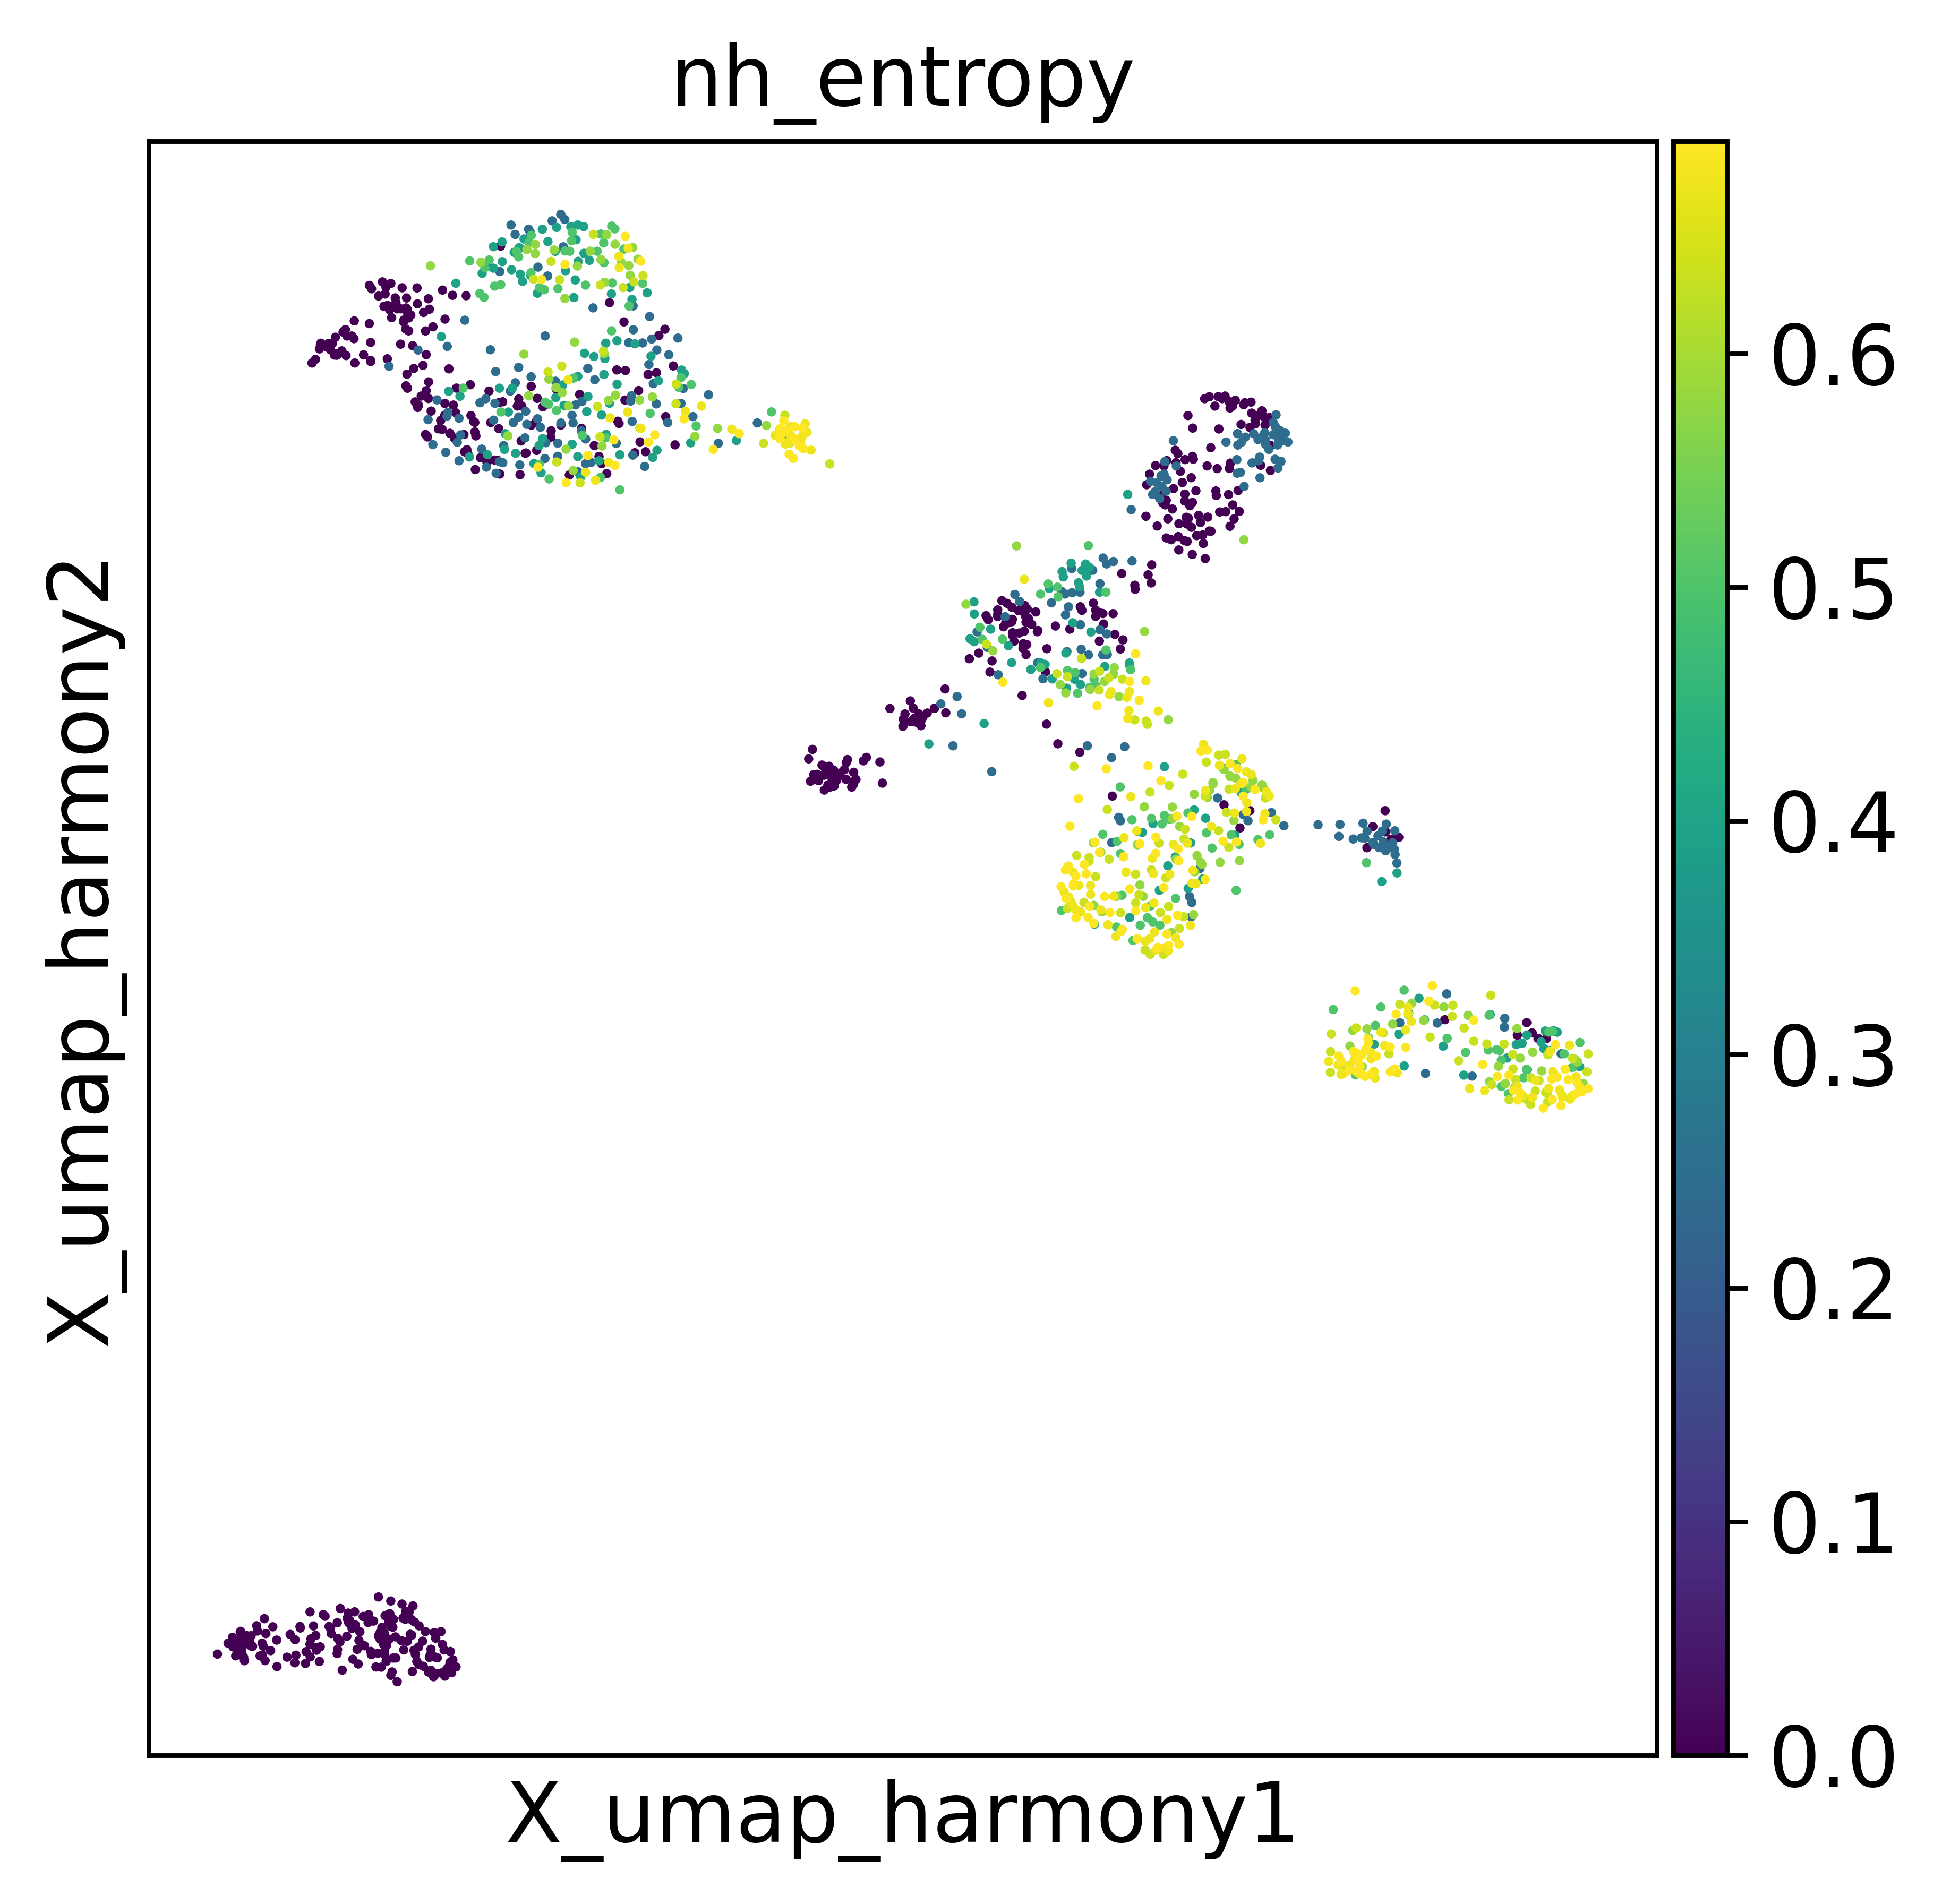

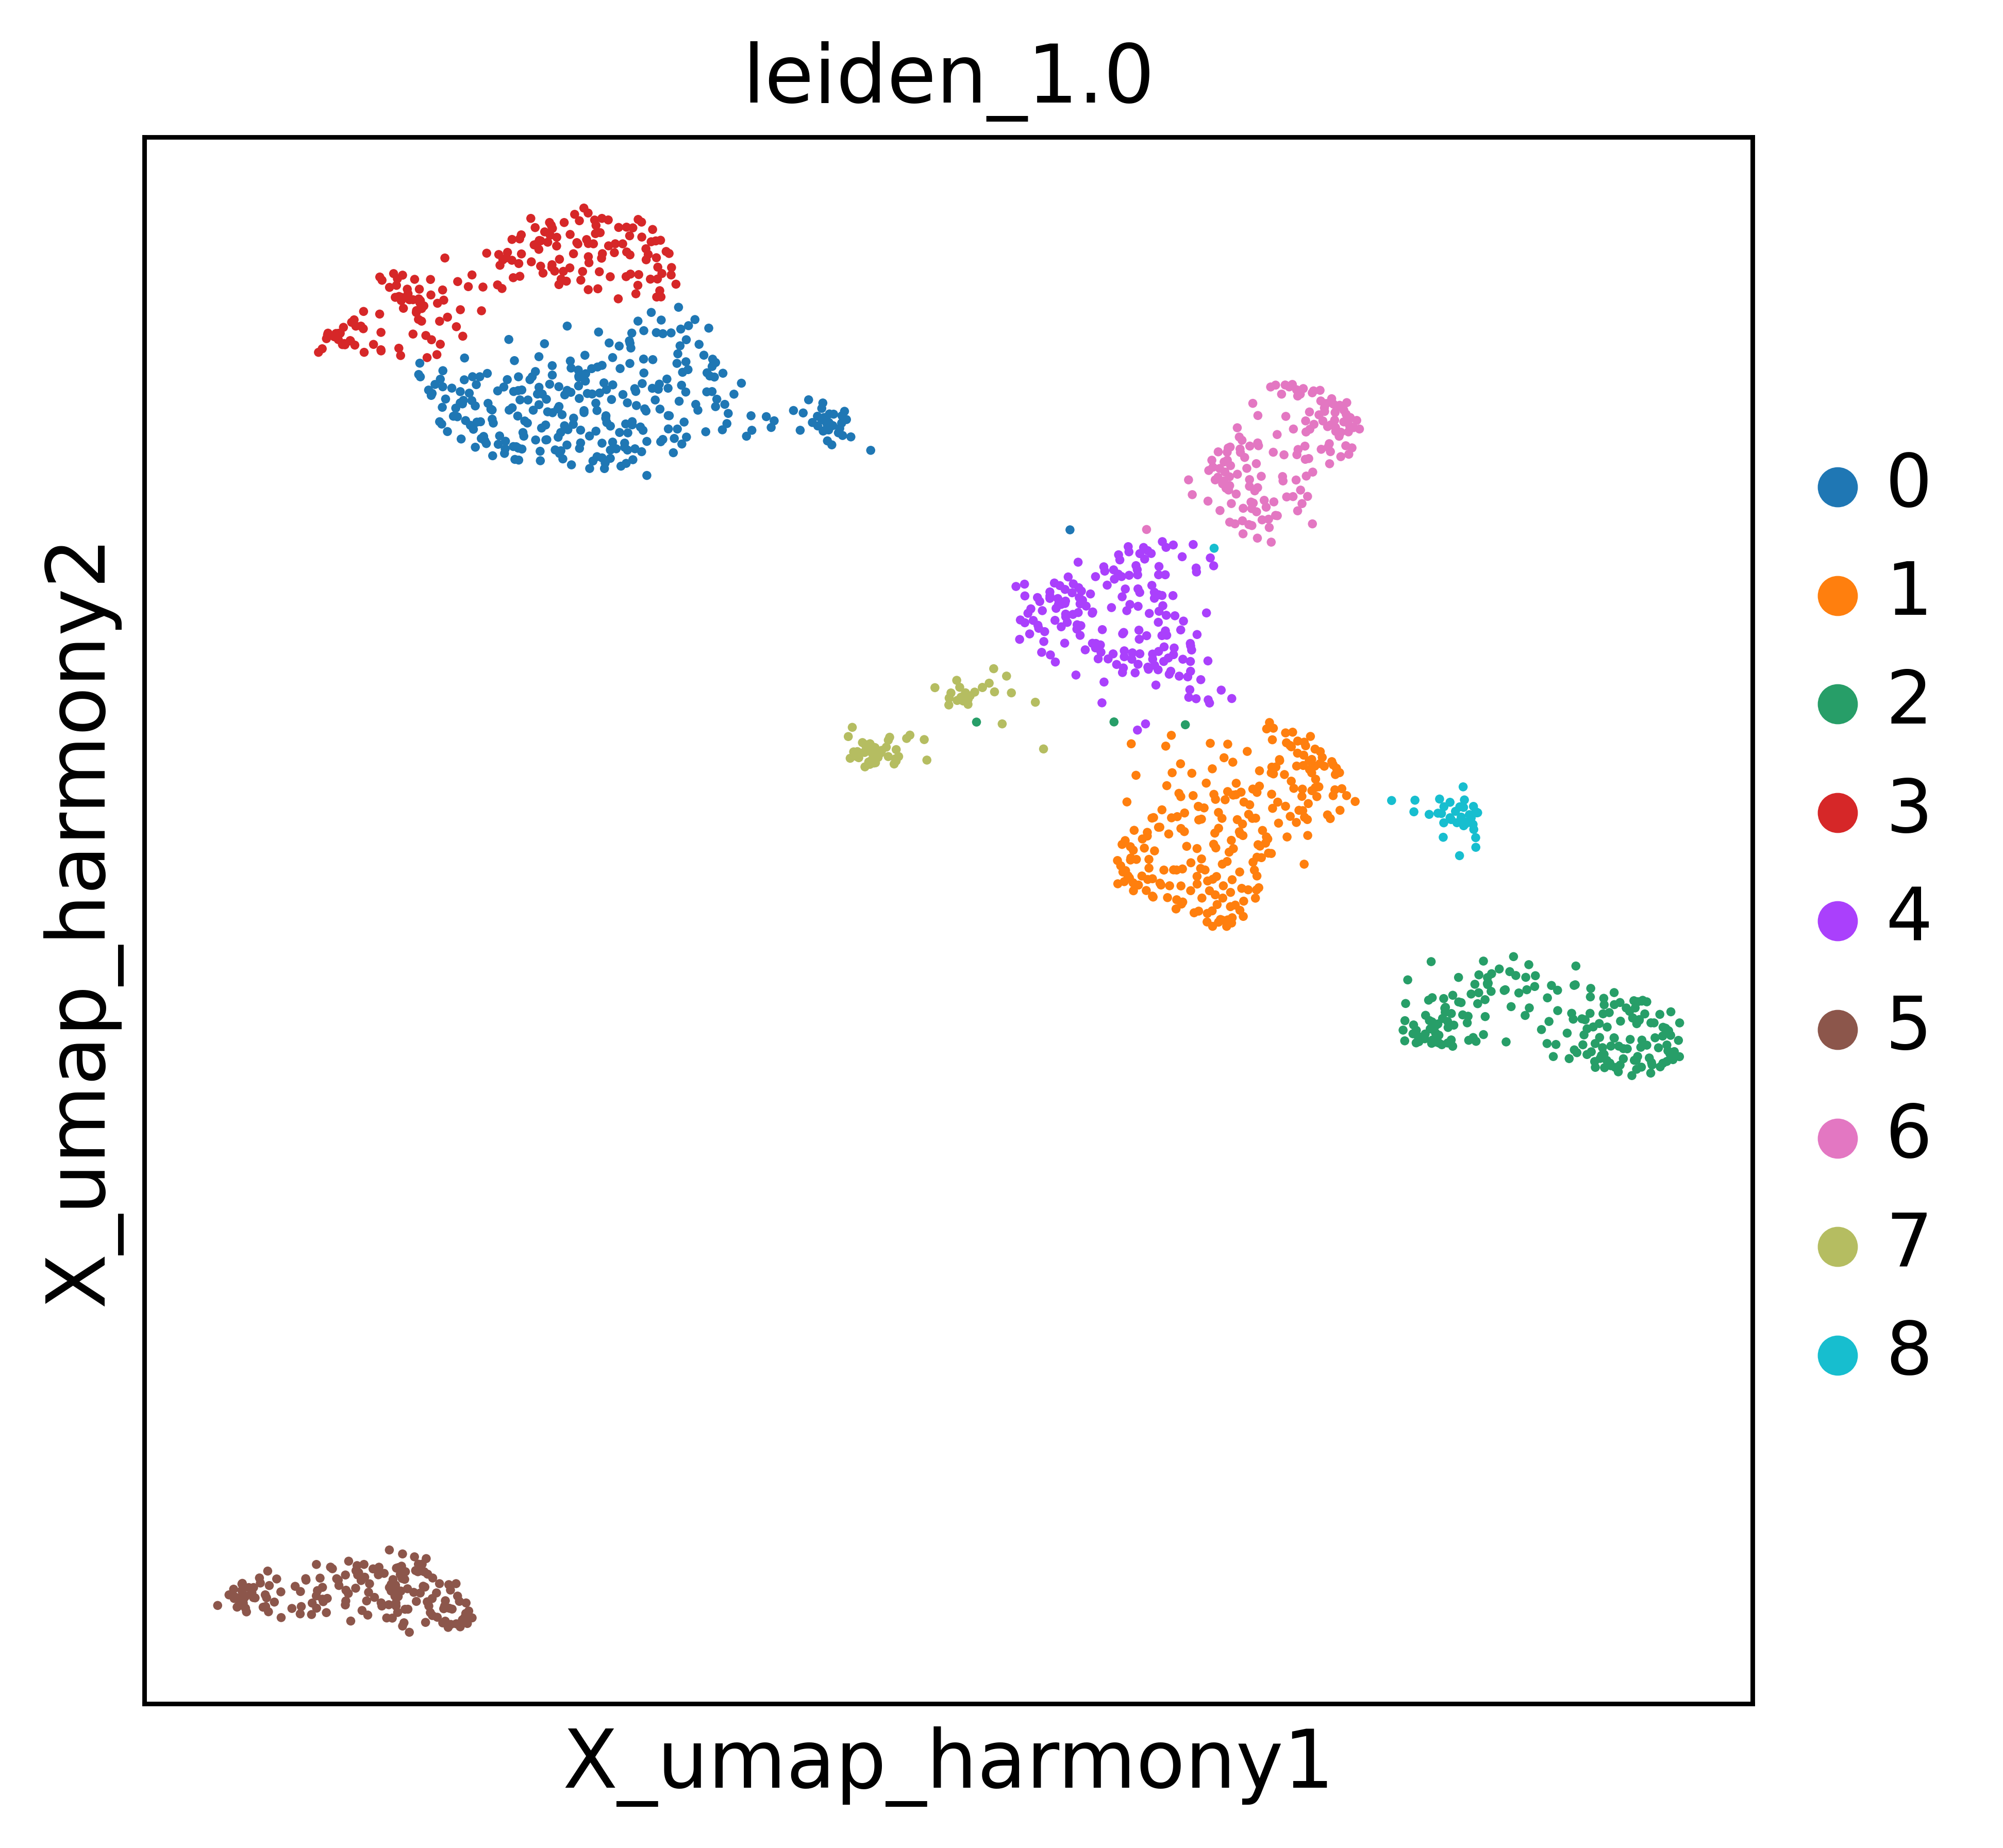

In [65]:
sc.pl.embedding(adata,basis=embedding,color = 'nh_entropy',size =10)
sc.pl.embedding(adata,basis=embedding,color = 'leiden_1.0',size =10)

In [70]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,animal_id,doublet_score,mito.ratio,malat1,sex,age,load_name,...,leiden_small_geneXcell_nb,leiden_medium_geneXcell_nb,leiden_large_geneXcell_cell_nb,leiden_Xlarge_geneXcell_cell_nb,leiden_harmony,leiden_proxy,leiden_2.0,leiden_1.0,tech_entropy,nh_entropy
AB-S40360_S744_E1-50,AB-S40360,1000000.0,3402.0,730617,NaN,0.004448,14.529826,M,71 days,NaN,...,0,0,0,0,0,6,9,4,0.000000,0.000000
AB-S40361_S562_E1-50,AB-S40361,1000000.0,6988.0,730618,NaN,0.001540,15.004264,F,71 days,NaN,...,1,1,1,1,1,13,6,2,0.690923,0.690923
AB-S40361_S565_E1-50,AB-S40361,1000000.0,7054.0,730618,NaN,0.006185,15.085350,F,71 days,NaN,...,2,1,2,2,2,14,1,1,0.690923,0.690923
AB-S40361_S569_E1-50,AB-S40361,1000000.0,6689.0,730619,NaN,0.003169,13.524849,F,71 days,NaN,...,2,1,2,2,2,15,1,1,0.690923,0.690923
AB-S40361_S571_E1-50,AB-S40361,1000000.0,8218.0,730619,NaN,0.005395,10.749350,F,71 days,NaN,...,2,1,2,2,2,16,12,1,0.673012,0.673012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGAGCTAGAGCCGCT-L8XR_250123_21_C08-68cc52a35d408ad9ac877c3b9f22592fed4dc9d8,MouseCMG_dissection_test,3692.0,1933.0,766666,0.276596,NaN,12.605175,NaN,NaN,2672_B06,...,0,0,0,0,0,80,9,4,0.579915,0.579915
TTGCAATCAGGCATCT-L8XR_250123_21_C08-68cc52a35d408ad9ac877c3b9f22592fed4dc9d8,MouseCMG_dissection_test,2430.0,1023.0,766666,0.297872,NaN,12.270083,NaN,NaN,2672_B06,...,0,0,0,0,0,40,5,4,0.000000,0.000000
TTGGAGGCACTTGTTC-L8XR_250123_21_C08-68cc52a35d408ad9ac877c3b9f22592fed4dc9d8,MouseCMG_dissection_test,1333.0,732.0,766666,0.085106,NaN,11.551588,NaN,NaN,2672_B06,...,0,0,0,0,0,211,5,4,0.000000,0.000000
TTGTCCCAGCATGCAT-L8XR_250123_21_C08-68cc52a35d408ad9ac877c3b9f22592fed4dc9d8,MouseCMG_dissection_test,1524.0,688.0,766666,0.166667,NaN,13.264959,NaN,NaN,2672_B06,...,0,0,0,0,0,946,5,4,0.000000,0.000000


In [72]:
# are donors over/under-represented in clusters
import numpy as np, pandas as pd
from scipy.stats import binomtest, false_discovery_control

sub = adata.obs[adata.obs["tech"] == "10x_Multiome"]     # keep platform out of it
tab = pd.crosstab(sub["leiden_1.0"], sub["animal_id"])
donor_share = tab.sum(0) / tab.values.sum()
top = tab.idxmax(axis=1)

s = pd.DataFrame({
    "n_cells": tab.sum(1),
    "n_donors_present": (tab > 0).sum(1),
    "top_donor": top,
    "top_donor_frac": tab.max(1) / tab.sum(1),
    "expected_frac": top.map(donor_share),
})
s["enrichment"] = s["top_donor_frac"] / s["expected_frac"]
s["p"] = [binomtest(int(tab.loc[c].max()), int(tab.loc[c].sum()),
                    float(donor_share[top[c]]), alternative="greater").pvalue
          for c in tab.index]
s["q"] = false_discovery_control(s["p"])


In [73]:
s

,n_cells,n_donors_present,top_donor,top_donor_frac,expected_frac,enrichment,p,q
leiden_1.0,,,,,,,,
0,210,6,680250,0.914286,0.480957,1.900973,3.507808e-41,1.052342e-40
1,123,6,692720,0.455285,0.209035,2.178035,8.675309e-10,1.115397e-09
2,82,6,692722,0.329268,0.137290,2.398348,7.650320e-06,8.606610e-06
3,161,3,680250,0.968944,0.480957,2.014619,8.417499e-43,3.787875e-42
4,142,5,692720,0.323944,0.209035,1.549714,9.298159e-04,9.298159e-04
5,169,1,680250,1.000000,0.480957,2.079190,1.887535e-54,1.698782e-53
6,143,5,692720,0.482517,0.209035,2.308315,3.407004e-13,6.132608e-13
7,65,4,692722,0.461538,0.137290,3.361787,2.803379e-10,4.205069e-10
8,34,1,692720,1.000000,0.209035,4.783898,7.716388e-24,1.736187e-23


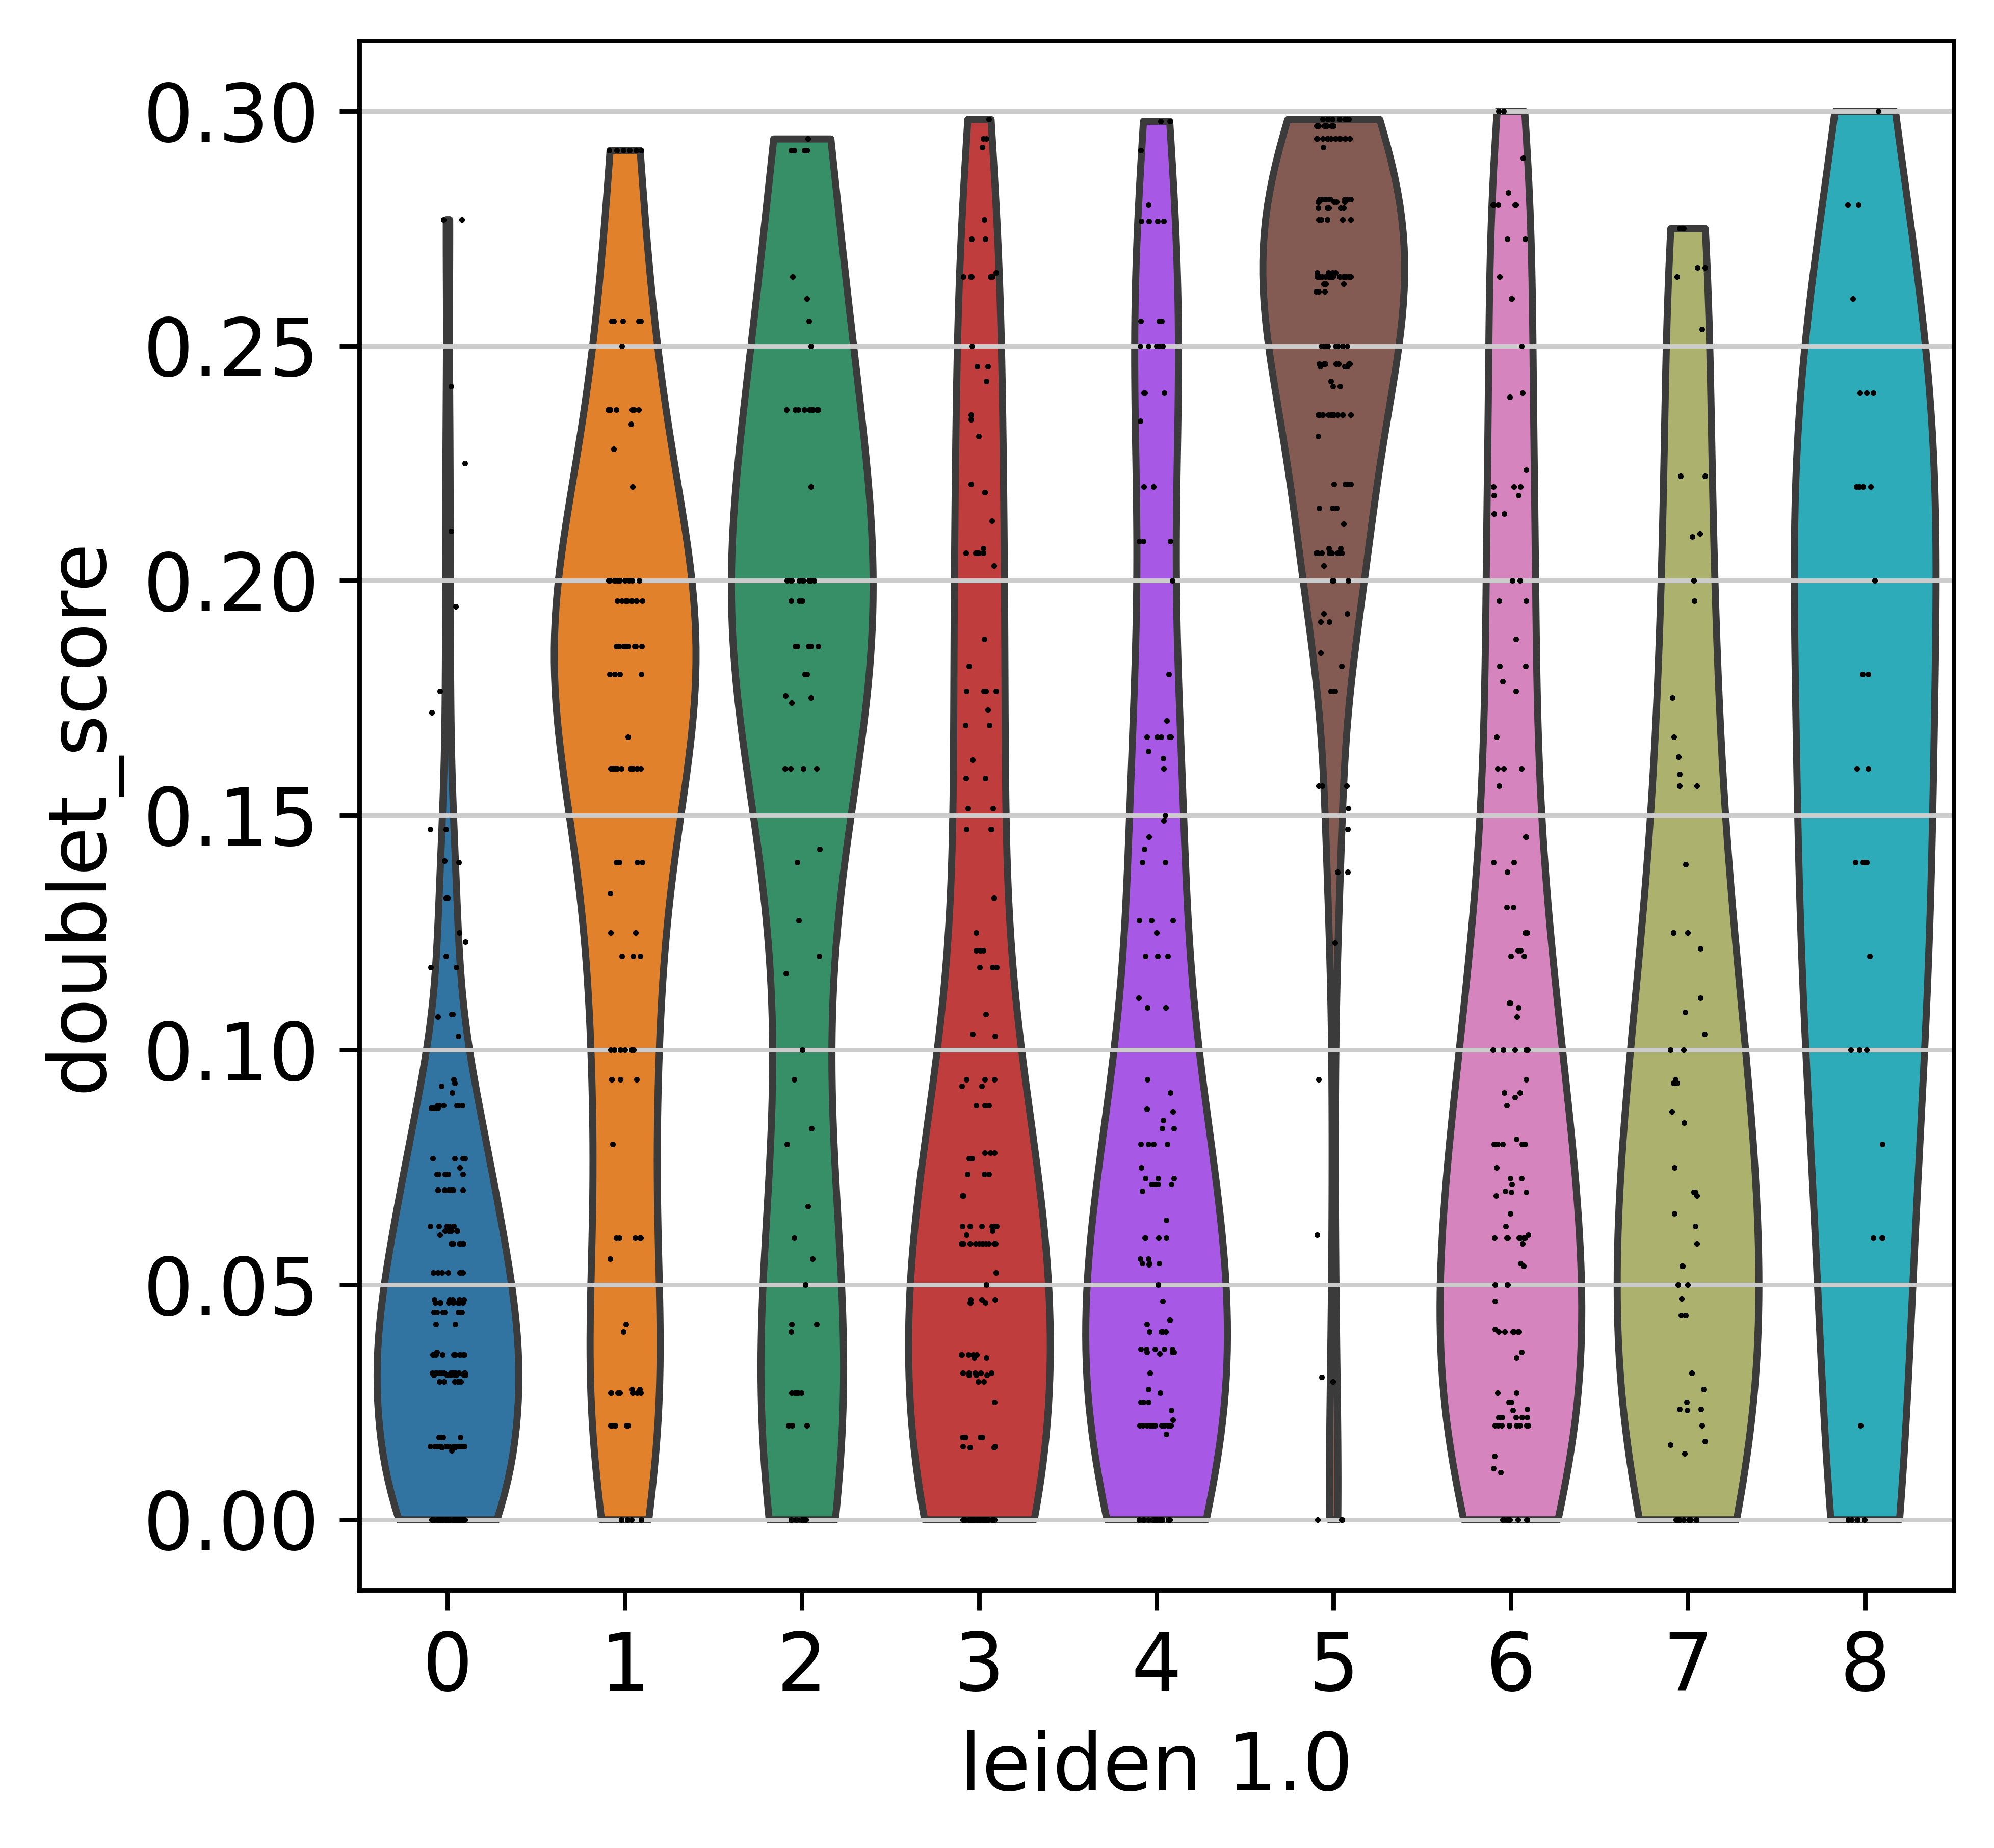

In [64]:
# doublet clusters?
sc.pl.violin(adata,'doublet_score','leiden_1.0')